# Organize all the observations you have into one dataset

In [1]:
# Taken from /ocean/rbeutel/MOAD/analysis-becca/LiveOcean/tracers/myobs.ipynb

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
import gsw
import datetime as dt
import matplotlib.pyplot as plt

from cartopy import crs, feature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import warnings
warnings.filterwarnings("ignore")

orig_path = "/ocean/rbeutel/MOAD/analysis-becca/LiveOcean/tracers"

In [3]:
grid = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/LiveOcean/grid.nc')

### unit conversion functions

In [4]:
def umolkg_to_uM(umolkg, temp_in_situ, salinity_absolute, pressure):
    """
    Convet from µmol/kg to µM (µmol/L) using in-situ temperature, salinity, and pressure.
    note - not to be used of oxygen or other dissolved gasses (keep those in umol/kg)
    
    Parameters:
    - temp_in_situ: In-situ temperature in degrees Celsius.
    - salinity_absolute: Absolute salinity in g/kg.
    - pressure: Pressure in dbar (default is 0, corresponding to surface).
    
    Returns:
    - Dissolved oxygen in µM (µmol/L).
    """
    # Calculate seawater density using TEOS-10
    conservative_temp = gsw.CT_from_t(salinity_absolute, temp_in_situ, pressure)
    density_seawater = gsw.rho(salinity_absolute, conservative_temp, pressure)  # Density in kg/m^3
    
    # Convert µmol/kg to µmol/L (µM) using the seawater density
    uM = umolkg * (density_seawater / 1000)  # density_seawater is in kg/m^3, so divide by 1000 to convert to L
    
    return uM


def oxygen_mlL_to_umolkg(oxygen_mlL, temp_in_situ, salinity_absolute, pressure):
    """
    Convert dissolved oxygen from mL/L to µmol/kg using in-situ temperature, salinity, and pressure.
    
    Parameters:
    - oxygen_mlL: Dissolved oxygen in mL/L.
    - temp_in_situ: In-situ temperature in degrees Celsius.
    - salinity_absolute: Absolute salinity in g/kg.
    - pressure: Pressure in dbar
    
    Returns:
    - Dissolved oxygen in µmol/kg
    """
    # # empirical conversion from Crawford and Pena (2013)
    # C = 43.7 # umol/kg per 1 ml/L

    # conversion based upon molar volume of oxygen at STP
    # should result in similar value to Crawford and Pena +/- <1%, but slightly more accurate to use density 
    C = 44660

    # density
    conservative_temp = gsw.CT_from_t(salinity_absolute, temp_in_situ, pressure)
    density_seawater = gsw.rho(salinity_absolute, conservative_temp, pressure)
    
    # Convert mL/L to µmol/L using the in-situ molar volume
    oxygen_umolkg = (oxygen_mlL * C) / density_seawater
    
    return oxygen_umolkg

def oxygen_uM_to_umolkg(oxygen_uM, temp_in_situ, salinity_absolute, pressure):
    """
    Convert dissolved oxygen from uM to µmol/kg using in-situ temperature, salinity, and pressure.
    
    Parameters:
    - oxygen_uM: Dissolved oxygen in uM.
    - temp_in_situ: In-situ temperature in degrees Celsius.
    - salinity_absolute: Absolute salinity in g/kg.
    - pressure: Pressure in dbar
    
    Returns:
    - Dissolved oxygen in µmol/kg
    """
    # density
    conservative_temp = gsw.CT_from_t(salinity_absolute, temp_in_situ, pressure)
    density_seawater = gsw.rho(salinity_absolute, conservative_temp, pressure)
    
    # Convert mL/L to µmol/L using the in-situ molar volume
    oxygen_umolkg = (oxygen_uM / density_seawater) * 1000
    
    return oxygen_umolkg


def metals_nM_to_nmolkg(metal_nM, temp_in_situ, salinity_absolute, pressure):
    """
    Convert trace metals from nM to µmol/kg using in-situ temperature, salinity, and pressure. 
    We do this because most previous research reported trace metals this way.
    
    Parameters:
    - metal_nM: trace metal in nM (nmol/L).
    - temp_in_situ: In-situ temperature in degrees Celsius.
    - salinity_absolute: Absolute salinity in g/kg.
    - pressure: Pressure in dbar
    
    Returns:
    - Trace metal concentration in nmol/kg
    """
    # density
    conservative_temp = gsw.CT_from_t(salinity_absolute, temp_in_situ, pressure)
    density_seawater = gsw.rho(salinity_absolute, conservative_temp, pressure)
    
    # Convert mL/L to µmol/L using the in-situ molar volume
    metal_nmolkg = (metal_nM / density_seawater) * 1000
    
    return metal_nmolkg

### QA/QC functions

In [5]:
def _stdev(df, tracer):
    # cutoff outliers according to the standard deviation 
    data = df[tracer]

    # most data shouldn't have negative values so we can remove those
    # temperature can be slightly negative at the surface in the winter
    if tracer == 'temperature (degC)':
        lcut = -2
    else:
        lcut = 0

    # remove data less than lcut
    data[data<lcut] = np.nan # this line is changing temp[tracer] and idk why... but i guess that's OK

    # we want the standard deviation calculation to change with depth, so a new calc for a series of depth bins
    # lets do a bin every 100 m

    # depth binning:
    if np.max(df['depth (m)']) == np.min(df['depth (m)']):
        z = 0
    elif np.max(df['depth (m)']) > 1000:
        z = np.append(np.append(np.append(np.arange(0,50,10),np.arange(50,1000,50)),np.arange(1000,np.max(df['depth (m)']),300)),np.max(df['depth (m)']))
    else:
        z = np.append(np.arange(0,50,10),np.arange(50,np.max(df['depth (m)'])+1,50))


    if np.max(z) == 0:
            std = np.nanstd(data)
            mean = np.nanmean(data)
            z=0

            rcut = mean + 4*std
            lcut = mean - 4*std
    else:
        lcut, rcut = np.zeros(len(z)-1), np.zeros(len(z)-1)
        for i in range(len(z)-1):
            d = data[(df['depth (m)']>z[i]) & (df['depth (m)']<z[i+1])]

            std = np.nanstd(d)
            mean = np.nanmean(d)

            rcut[i] = mean + 4*std
            lcut[i] = mean - 4*std

    # for salinity at the surface we can have data all the way to zero (even if outside of stdev)
    if tracer == 'salinity (g kg-1)':
        lcut[0] = 0

    return lcut, rcut, z

def qaqc_plot(df, tracer, ax):
    #exploratory version of the stdev()
    lcut, rcut, z = _stdev(df, tracer)

    # plot original data with these cuttoffs 
    ax.scatter(df[tracer],df['depth (m)'], s=1)
    ax.set_title(tracer)
    ax.set_ylim([np.max(df['depth (m)']), -10])

    # and the cutoffs
    for i in range(len(z)-1):
        ax.plot([lcut[i],lcut[i]],[z[i], z[i+1]],'k--')
        ax.plot([rcut[i],rcut[i]],[z[i], z[i+1]],'k--')

def qaqc_trim(df, tracer):
    lcut, rcut, z = _stdev(df,tracer)

    if np.max(z) == 0:
        df[tracer][df[tracer] > rcut] = np.nan
        df[tracer][df[tracer] < lcut] = np.nan
    else:
        for i in range(len(z)-1):
            df[tracer][(df['depth (m)']>=z[i]) & (df['depth (m)']<z[i+1]) & (df[tracer] > rcut[i])] = np.nan
            df[tracer][(df['depth (m)']>=z[i]) & (df['depth (m)']<z[i+1]) & (df[tracer] < lcut[i])] = np.nan

    return df[tracer]


In [6]:
# note: uM = umol/L
d = {'time':[],'source':[],'longitude (degrees_east)':[],'latitude (degrees_north)':[],'depth (m)':[],'pressure (dbar)':[],
    'temperature (degC)':[], 'salinity (g kg-1)':[], 'DO (umol kg-1)':[], 'NO3 (uM)':[], 'NO2 (uM)':[], 'NH4 (uM)':[], 'PO4 (uM)':[], 'SiO4 (uM)':[], 
    'Chl (mg m-3)':[], 'TA (uM)':[], 'DIC (uM)':[], 'Carbonate':[], 'Aragonite':[], 'Calcite':[], 'Cd (nmol kg-1)':[],'Co (nmol kg-1)':[], 'Cu (nmol kg-1)':[], 'Fe (nmol kg-1)':[],
    'Mn (nmol kg-1)':[], 'Ni (nmol kg-1)':[], 'Zn (nmol kg-1)':[]}

ob = pd.DataFrame(d)

### IOS mooring

In [7]:
m2005 =pd.read_pickle(orig_path+'/observations/IOS_ctd_moor_2005.p')
m2010 =pd.read_pickle(orig_path+'/observations/IOS_ctd_moor_2010.p')
m2015 =pd.read_pickle(orig_path+'/observations/IOS_ctd_moor_2015.p')
m2020 =pd.read_pickle(orig_path+'/observations/IOS_ctd_moor_2020.p')
ios_moor = pd.concat([m2005,m2010,m2015,m2020])
ios_moor.head()

,longitude (degrees_east),latitude (degrees_north),sea_water_pressure (dbar),depth (m),sea_water_temperature (degC),sea_water_practical_salinity (PSS-78),DOXYZZ01 (mL/L),time
0,-123.42445,49.027150,13.177000,13.064797,9.5504,28.440600,NaN,2008-11-19 00:00:00+00:00
263,-126.20380,48.529415,34.192333,33.900998,NaN,32.213500,NaN,2008-11-13 00:00:00+00:00
264,-126.20380,48.529415,34.137667,33.846801,NaN,32.215658,NaN,2008-11-14 00:00:00+00:00
265,-126.20380,48.529415,34.178923,33.887704,NaN,32.214500,NaN,2008-11-15 00:00:00+00:00
266,-126.20380,48.529415,34.135000,33.844159,NaN,32.212792,NaN,2008-11-16 00:00:00+00:00


In [8]:
# convert to correct units
ios_moor['SA'] = gsw.conversions.SA_from_SP(ios_moor['sea_water_practical_salinity (PSS-78)'],ios_moor['sea_water_pressure (dbar)'],ios_moor['longitude (degrees_east)'],ios_moor['latitude (degrees_north)'])
ios_moor['DO'] = oxygen_mlL_to_umolkg(ios_moor['DOXYZZ01 (mL/L)'], ios_moor['sea_water_temperature (degC)'], ios_moor.SA, ios_moor['sea_water_pressure (dbar)'])

# add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(ios_moor.time)
temp['longitude (degrees_east)'] = pd.to_numeric(ios_moor['longitude (degrees_east)'], errors='coerce')
temp['latitude (degrees_north)'] = pd.to_numeric(ios_moor['latitude (degrees_north)'], errors='coerce')
temp['pressure (dbar)'] = pd.to_numeric(ios_moor['sea_water_pressure (dbar)'], errors='coerce')
temp['depth (m)'] = pd.to_numeric(ios_moor['depth (m)'], errors='coerce')
temp['temperature (degC)'] = pd.to_numeric(ios_moor['sea_water_temperature (degC)'], errors='coerce')
temp['salinity (g kg-1)'] = pd.to_numeric(ios_moor['SA'], errors='coerce')
temp['DO (umol kg-1)'] = pd.to_numeric(ios_moor['DO'], errors='coerce')
temp['source'] ="ios mooring"

# ob = pd.concat([ob, temp])


In [9]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))

max = 35.16746847412088, min = -99.47638976603683, mean = 32.067606611586044
max = 14.947814285714285, min = -1.8402, mean = 7.769119365306907
max = 344.2654435801368, min = 33.70136364466377, mean = 160.28624222985027


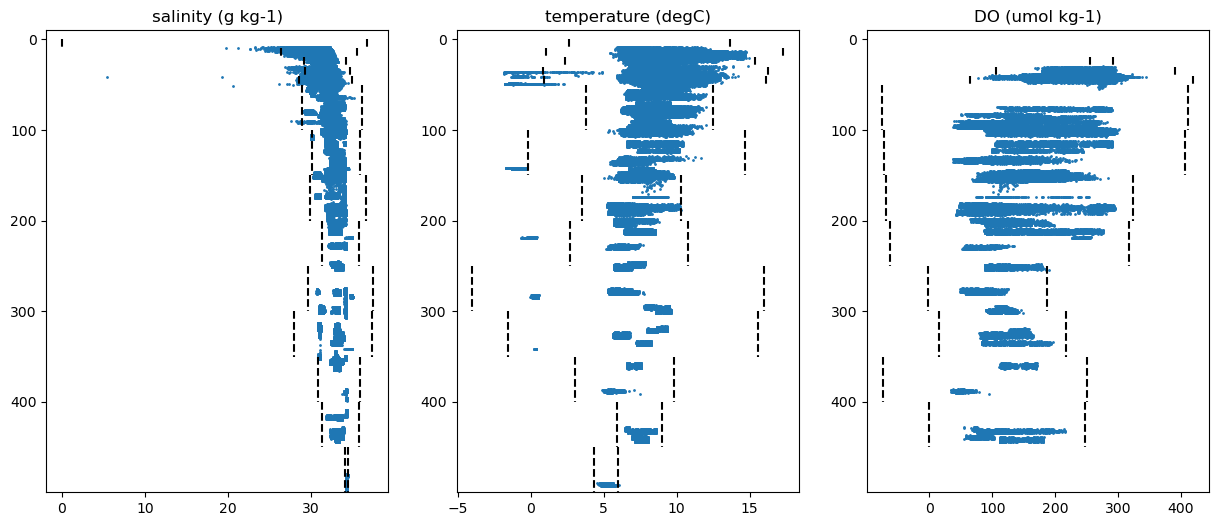

In [10]:
fig, ax = plt.subplots(1,3, figsize = (15, 6))

qaqc_plot(temp, 'salinity (g kg-1)', ax[0])
qaqc_plot(temp, 'temperature (degC)', ax[1])
qaqc_plot(temp, 'DO (umol kg-1)', ax[2])

In [11]:
# trim based on standard deviation 
temp['salinity (g kg-1)'] = qaqc_trim(temp, 'salinity (g kg-1)')
temp['temperature (degC)'] = qaqc_trim(temp, 'temperature (degC)')
temp['DO (umol kg-1)'] = qaqc_trim(temp, 'DO (umol kg-1)')

# add to main df
ob = pd.concat([ob, temp])

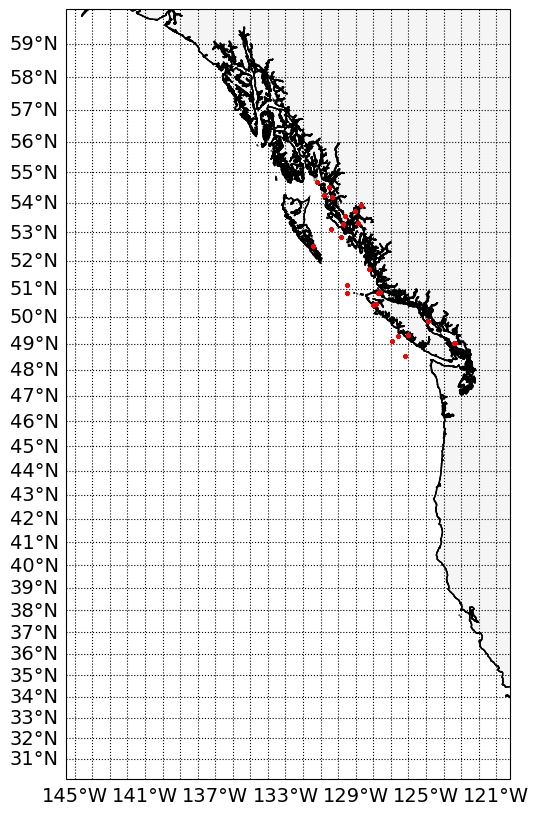

In [12]:
tracer = 'temperature (degC)'
# Increase font size
plt.rcParams['font.size'] = 14

# Make plot area
xlim, ylim = [-145.5, -120.2], [30, 60]
fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
ax.set_extent(xlim + ylim)

# Draw coastline
ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

# Add gridlines
xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
gl.top_labels, gl.right_labels = False, False

# add points
ax.scatter(temp['longitude (degrees_east)'][~np.isnan(temp[tracer])], temp['latitude (degrees_north)'][~np.isnan(temp[tracer])], s=4, c='r', transform=crs.PlateCarree(),zorder=7)

### IOS ctd profiles

In [13]:
filenames = [orig_path+'/observations/IOS_ctd_prof_{}.p'.format(year) for year in np.arange(1965,2023+1,1)]

df_from_each_file = (pd.read_pickle(f) for f in filenames)
ios_prof = pd.concat(df_from_each_file, ignore_index=True)
ios_prof.head()

,longitude (degrees_east),latitude (degrees_north),sea_water_pressure (dbar),depth (m),sea_water_temperature (degC),sea_water_practical_salinity (PSS-78),DOXYZZ01 (mL/L),time,time (UTC)
0,-123.52,49.06,2.017128,2.0,NaN,23.640284,NaN,1965-07-07 00:00:00+00:00,NaT
1,-123.11,48.93,2.017104,2.0,NaN,27.491588,NaN,1965-07-07 00:00:00+00:00,NaT
2,-123.10,48.93,2.017104,2.0,NaN,28.930536,NaN,1965-07-07 00:00:00+00:00,NaT
3,-123.09,48.91,2.017100,2.0,NaN,28.481104,NaN,1965-07-06 00:00:00+00:00,NaT
4,-123.34,48.97,3.025674,3.0,NaN,15.893637,NaN,1965-07-07 00:00:00+00:00,NaT


In [14]:
# convert to correct units
ios_prof['SA'] = gsw.conversions.SA_from_SP(ios_prof['sea_water_practical_salinity (PSS-78)'],ios_prof['sea_water_pressure (dbar)'],ios_prof['longitude (degrees_east)'],ios_prof['latitude (degrees_north)'])
ios_prof['DO'] = oxygen_mlL_to_umolkg(ios_prof['DOXYZZ01 (mL/L)'], ios_prof['sea_water_temperature (degC)'], ios_prof.SA, ios_prof['sea_water_pressure (dbar)'])

# add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(ios_prof.time)
temp['longitude (degrees_east)'] = ios_prof['longitude (degrees_east)']
temp['latitude (degrees_north)'] = ios_prof['latitude (degrees_north)']
temp['pressure (dbar)'] = ios_prof['sea_water_pressure (dbar)']
temp['depth (m)'] = ios_prof['depth (m)']
temp['temperature (degC)'] = ios_prof['sea_water_temperature (degC)']
temp['salinity (g kg-1)'] = ios_prof['SA']
temp['DO (umol kg-1)'] = ios_prof['DO']
temp['source'] ="ios ctd profiles"

# ob = pd.concat([ob, temp])

In [15]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))

max = 80.88245130732513, min = -100.32904240977614, mean = 32.689111551578314
max = 30.550268, min = -98.97625, mean = 6.923419449973603
max = 605.9778238142137, min = -393.97400792999434, mean = 163.8191461376554


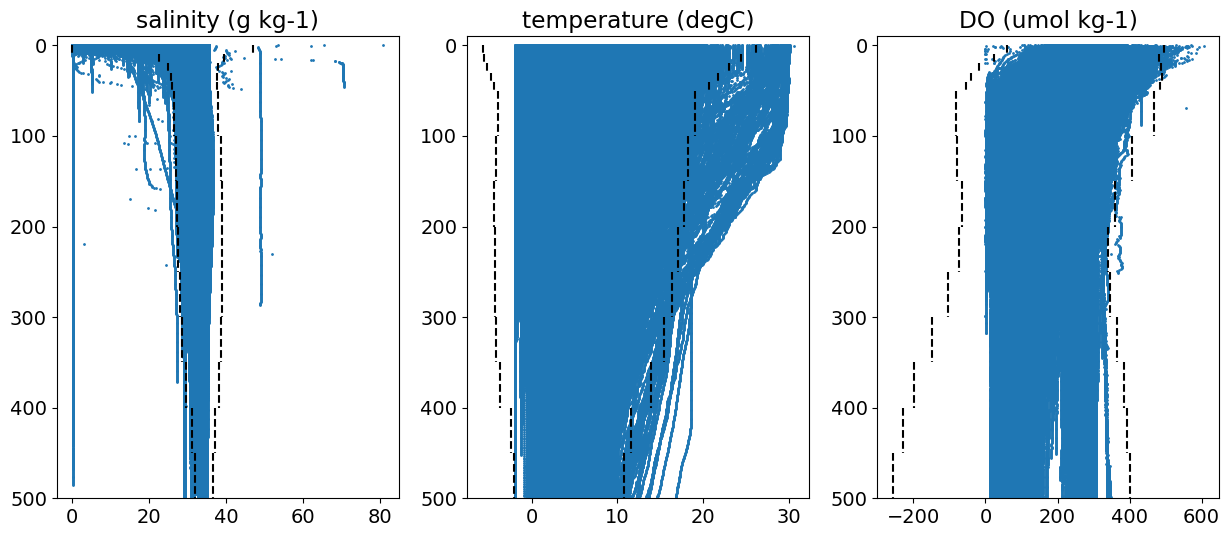

In [16]:
fig, ax = plt.subplots(1,3, figsize = (15, 6))

qaqc_plot(temp, 'salinity (g kg-1)', ax[0])
qaqc_plot(temp, 'temperature (degC)', ax[1])
qaqc_plot(temp, 'DO (umol kg-1)', ax[2])

In [17]:
# trim based on standard deviation 
temp['salinity (g kg-1)'] = qaqc_trim(temp, 'salinity (g kg-1)')
temp['temperature (degC)'] = qaqc_trim(temp, 'temperature (degC)')
temp['DO (umol kg-1)'] = qaqc_trim(temp, 'DO (umol kg-1)')

# add to main df
ob = pd.concat([ob, temp])

### IOS bottles

In [18]:
b1930 =pd.read_pickle(orig_path+'/observations/IOS_bot_prof_1930.p')
b1940 =pd.read_pickle(orig_path+'/observations/IOS_bot_prof_1940.p')
b1950 =pd.read_pickle(orig_path+'/observations/IOS_bot_prof_1950.p')
b1960 =pd.read_pickle(orig_path+'/observations/IOS_bot_prof_1960.p')
b1970 =pd.read_pickle(orig_path+'/observations/IOS_bot_prof_1970.p')
b1980 =pd.read_pickle(orig_path+'/observations/IOS_bot_prof_1980.p')
b1990 =pd.read_pickle(orig_path+'/observations/IOS_bot_prof_1990.p')
b2000 =pd.read_pickle(orig_path+'/observations/IOS_bot_prof_2000.p')
b2010 =pd.read_pickle(orig_path+'/observations/IOS_bot_prof_2010.p')
b2020 =pd.read_pickle(orig_path+'/observations/IOS_bot_prof_2020.p')
ios_bot = pd.concat([b1930, b1940,b1950,b1960,b1970,b1980,b1990,b2000,b2010,b2020])
ios_bot.head()

,longitude (degrees_east),latitude (degrees_north),sea_water_pressure (dbar),depth (m),sea_water_temperature (degC),sea_water_practical_salinity (PSS-78),DOXYZZ01 (mL/L),DOXMZZ01 (umol/kg),NTRZAAZ1 (umol/L),SLCAAAZ1 (umol/L),PHOSAAZ1 (umol/L),CPHLFLP1 (mg/m^3),time
0,-133.363,54.673,0.0,0.0,NaN,31.957418,6.33,NaN,NaN,NaN,NaN,NaN,1938-05-29 00:00:00+00:00
1,-133.335,54.553,0.0,0.0,NaN,32.177610,6.33,NaN,NaN,NaN,NaN,NaN,1938-05-29 00:00:00+00:00
2,-133.287,54.190,0.0,0.0,NaN,31.527050,6.66,NaN,NaN,NaN,NaN,NaN,1938-05-30 00:00:00+00:00
3,-133.253,54.420,0.0,0.0,NaN,31.266827,7.00,NaN,NaN,NaN,NaN,NaN,1938-05-29 00:00:00+00:00
4,-133.183,54.270,0.0,0.0,NaN,31.507032,6.89,NaN,NaN,NaN,NaN,NaN,1938-05-30 00:00:00+00:00


In [19]:
# convert to correct units
ios_bot['SA'] = gsw.conversions.SA_from_SP(ios_bot['sea_water_practical_salinity (PSS-78)'],ios_bot['sea_water_pressure (dbar)'],ios_bot['longitude (degrees_east)'],ios_bot['latitude (degrees_north)'])
ios_bot['DO'] = oxygen_mlL_to_umolkg(ios_bot['DOXYZZ01 (mL/L)'], ios_bot['sea_water_temperature (degC)'], ios_bot.SA, ios_bot['sea_water_pressure (dbar)'])

# add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(ios_bot.time)
temp['longitude (degrees_east)'] = ios_bot['longitude (degrees_east)']
temp['latitude (degrees_north)'] = ios_bot['latitude (degrees_north)']
temp['pressure (dbar)'] = ios_bot['sea_water_pressure (dbar)']
temp['depth (m)'] = ios_bot['depth (m)']
temp['temperature (degC)'] = ios_bot['sea_water_temperature (degC)']
temp['salinity (g kg-1)'] = ios_bot['SA']
temp['DO (umol kg-1)'] = ios_bot['DO']
temp['NO3 (uM)'] = ios_bot['NTRZAAZ1 (umol/L)']
temp['PO4 (uM)'] = ios_bot['PHOSAAZ1 (umol/L)']
temp['SiO4 (uM)'] = ios_bot['SLCAAAZ1 (umol/L)']
temp['Chl (mg m-3)'] = ios_bot['CPHLFLP1 (mg/m^3)']

temp['source'] ="ios bottle"

# ob = pd.concat([ob, temp])

In [20]:
temp['time'] = pd.to_datetime(temp.time, utc=True)
temp['longitude (degrees_east)'] = pd.to_numeric(temp['longitude (degrees_east)'], errors='coerce')
temp['latitude (degrees_north)'] = pd.to_numeric(temp['latitude (degrees_north)'], errors='coerce')
temp['depth (m)'] = pd.to_numeric(temp['depth (m)'], errors='coerce')
temp['pressure (dbar)'] = pd.to_numeric(temp['pressure (dbar)'], errors='coerce')
temp['temperature (degC)'] = pd.to_numeric(temp['temperature (degC)'], errors='coerce')
temp['salinity (g kg-1)'] = pd.to_numeric(temp['salinity (g kg-1)'], errors='coerce')
temp['DO (umol kg-1)'] = pd.to_numeric(temp['DO (umol kg-1)'], errors='coerce')
temp['NO3 (uM)'] = pd.to_numeric(temp['NO3 (uM)'], errors='coerce')
temp['PO4 (uM)'] = pd.to_numeric(temp['PO4 (uM)'], errors='coerce')
temp['SiO4 (uM)'] = pd.to_numeric(temp['SiO4 (uM)'], errors='coerce')

In [21]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO3 (uM)']),np.min(temp['NO3 (uM)']),np.mean(temp['NO3 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['PO4 (uM)']),np.min(temp['PO4 (uM)']),np.mean(temp['PO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['SiO4 (uM)']),np.min(temp['SiO4 (uM)']),np.mean(temp['SiO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['Chl (mg m-3)']),np.min(temp['Chl (mg m-3)']),np.mean(temp['Chl (mg m-3)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))

max = 93.3, min = -99.0, mean = 18.972690560514028
max = 708.0, min = -99.0, mean = 2.0667270031905423
max = 1080.0, min = -100.0, mean = 35.569668034537315
max = 191.2, min = -99.0, mean = 1.3402780921868056
max = 578.5086009460365, min = -4361.507575202596, mean = 214.1911304875138


In [22]:
# some (but not all) of this phostphate data is clearly in the wrong units
# removing date ranges where the values don't make sense (based on max >= 100 uM in waterproperties.ca)

# it seems like only dates in 1934 have these crazy values
# the silicate is also wild in these files 
# unfortunately i don't there's a way of knowing what units these were actually measured in so makes most sense to delete...
temp['PO4 (uM)'][(temp.time > pd.to_datetime("1934/4/30", utc=True)) & (temp.time < pd.to_datetime("1934/7/1", utc=True))] = np.nan
temp['SiO4 (uM)'][(temp.time > pd.to_datetime("1934/4/30", utc=True)) & (temp.time < pd.to_datetime("1934/7/1", utc=True))] = np.nan

In [23]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO3 (uM)']),np.min(temp['NO3 (uM)']),np.mean(temp['NO3 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['PO4 (uM)']),np.min(temp['PO4 (uM)']),np.mean(temp['PO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['SiO4 (uM)']),np.min(temp['SiO4 (uM)']),np.mean(temp['SiO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['Chl (mg m-3)']),np.min(temp['Chl (mg m-3)']),np.mean(temp['Chl (mg m-3)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))

# we clearly still have problems

max = 93.3, min = -99.0, mean = 18.972690560514028
max = 213.0, min = -99.0, mean = 1.772738453003146
max = 471.4, min = -100.0, mean = 35.23708639534225
max = 191.2, min = -99.0, mean = 1.3402780921868056
max = 578.5086009460365, min = -4361.507575202596, mean = 214.1911304875138


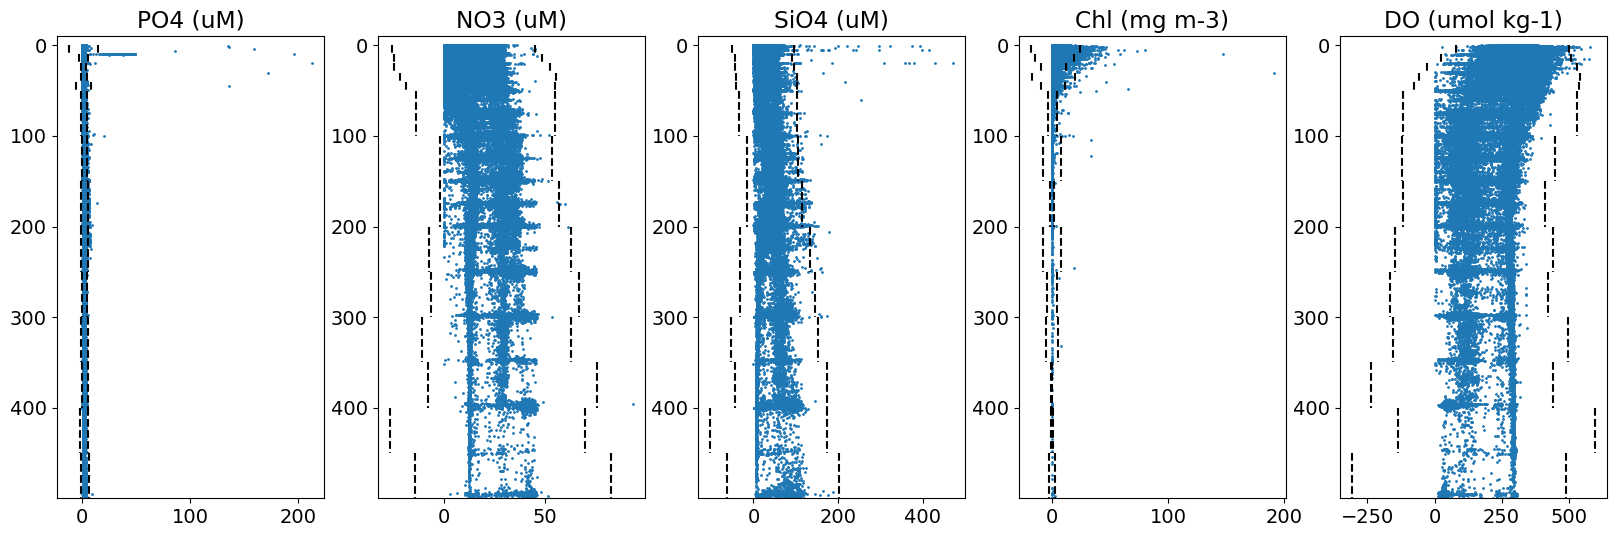

In [24]:
# lets see if there are any clear anomalies
test = ['PO4 (uM)', 'NO3 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)', 'DO (umol kg-1)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

In [25]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

In [26]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO3 (uM)']),np.min(temp['NO3 (uM)']),np.mean(temp['NO3 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['PO4 (uM)']),np.min(temp['PO4 (uM)']),np.mean(temp['PO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['SiO4 (uM)']),np.min(temp['SiO4 (uM)']),np.mean(temp['SiO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['Chl (mg m-3)']),np.min(temp['Chl (mg m-3)']),np.mean(temp['Chl (mg m-3)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))

max = 61.2, min = 0.0, mean = 19.017722608188954
max = 13.3, min = 0.0, mean = 1.7076073813349262
max = 188.0, min = 0.0, mean = 35.055711933025215
max = 24.0, min = 0.0, mean = 1.8964210453155408
max = 520.1198686322983, min = 0.0, mean = 214.9404394425993


In [27]:
ob = pd.concat([ob, temp])

In [28]:
    # Increase font size
    plt.rcParams['font.size'] = 14

    # Make plot area
    xlim, ylim = [-145.5, -120.2], [30, 60]
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
    ax.set_extent(xlim + ylim)

    # Draw coastline
    ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

    # Add gridlines
    xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
    gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.top_labels, gl.right_labels = False, False

# add points
ax.scatter(temp['longitude (degrees_east)'][~np.isnan(temp[tracer])], temp['latitude (degrees_north)'][~np.isnan(temp[tracer])], s=4, c='r', transform=crs.PlateCarree(),zorder=7)

IndentationError: unexpected indent (1482483090.py, line 2)

### OOI
i have some suspicions that these are completely covered by the NCEI Coastal dataset..

In [29]:
ooi_chl = pd.read_pickle('/ocean/rbeutel/MOAD/analysis-becca/LiveOcean/tracers/observations/OOI_chlorophyll.p')
ooi_chl.head()

# convert to correct units
ooi_chl['SA'] = gsw.conversions.SA_from_SP(ooi_chl['sea_water_practical_salinity (1e-3)'],ooi_chl['z (m)'],ooi_chl['longitude (degrees_east)'],ooi_chl['latitude (degrees_north)'])
# note microgram/L = mg/m3

# # add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(ooi_chl.datetime)
temp['longitude (degrees_east)'] = ooi_chl['longitude (degrees_east)']
temp['latitude (degrees_north)'] = ooi_chl['latitude (degrees_north)']
temp['pressure (dbar)'] = ooi_chl['z (m)']
temp['depth (m)'] = ooi_chl['z (m)']
temp['temperature (degC)'] = ooi_chl['sea_water_temperature (degree_Celsius)']
temp['salinity (g kg-1)'] = ooi_chl['SA']
temp['Chl (mg m-3)'] = ooi_chl['mass_concentration_of_chlorophyll_a_in_sea_water (microg.L-1)']
temp['source'] ="ooi"

# ob = pd.concat([ob, temp])

In [30]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['Chl (mg m-3)']),np.min(temp['Chl (mg m-3)']),np.mean(temp['Chl (mg m-3)'])))

max = 34.81133827729623, min = 0.0, mean = 31.705011213194215
max = 19.989569981186115, min = 1.7182868536, mean = 11.340365661640334
max = 5549.966065583712, min = -0.672, mean = 2.784790408035106


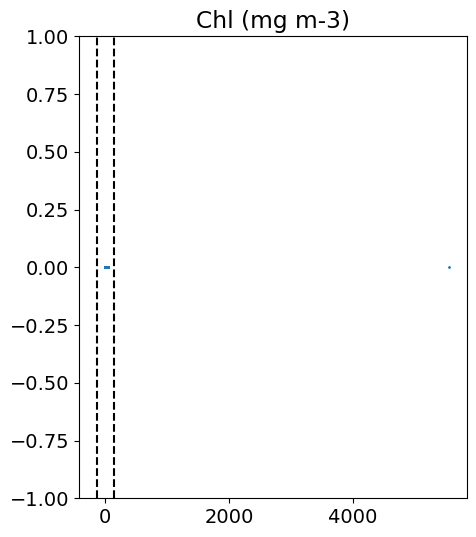

In [31]:
# something seems wrong with chlorophyll
# lets see if there are any clear anomalies
test = 'Chl (mg m-3)'
fig, ax = plt.subplots(1,1, figsize = (5, 6))
ax.scatter(temp[test],temp['depth (m)'], s=1, label=test)

ax.set_title(test)

ax.set_ylim([-1,1])

l, r, _ = _stdev(temp, test)
ax.plot([l,l],[-1,1],'k--')
ax.plot([r,r],[-1,1],'k--')

In [32]:
# trim based on standard deviation 
temp[test] = qaqc_trim(temp, test)

# and add to df
ob = pd.concat([ob, temp])

In [33]:
ooi_co2 = pd.read_pickle('/ocean/rbeutel/MOAD/analysis-becca/LiveOcean/tracers/observations/OOI_co2.p')
ooi_co2.head() # not included for now

,z (m),latitude (degrees_north),longitude (degrees_east),partial_pressure_of_carbon_dioxide_in_sea_water (microatm),partial_pressure_of_carbon_dioxide_in_sea_water_qc_agg,datetime
0,0.0,44.65695,-124.09553,681.410393,2.0,2014-04-21 00:00:00+00:00
1,NaN,NaN,NaN,NaN,NaN,2014-04-22 00:00:00+00:00
2,NaN,NaN,NaN,NaN,NaN,2014-04-23 00:00:00+00:00
3,NaN,NaN,NaN,NaN,NaN,2014-04-24 00:00:00+00:00
4,NaN,NaN,NaN,NaN,NaN,2014-04-25 00:00:00+00:00


In [34]:
ooi_oxy = pd.read_pickle('/ocean/rbeutel/MOAD/analysis-becca/LiveOcean/tracers/observations/OOI_oxygen.p')
ooi_oxy.head()

# # convert to correct units
ooi_oxy['SA'] = gsw.conversions.SA_from_SP(ooi_oxy['sea_water_practical_salinity (1e-3)'],ooi_oxy['z (m)'],ooi_oxy['longitude (degrees_east)'],ooi_oxy['latitude (degrees_north)'])

# # # add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(ooi_oxy.datetime)
temp['longitude (degrees_east)'] = ooi_oxy['longitude (degrees_east)']
temp['latitude (degrees_north)'] = ooi_oxy['latitude (degrees_north)']
temp['pressure (dbar)'] = ooi_oxy['z (m)']
temp['depth (m)'] = ooi_oxy['z (m)']
temp['temperature (degC)'] = ooi_oxy['sea_water_temperature (degree_Celsius)']
temp['salinity (g kg-1)'] = ooi_oxy['SA']
temp['DO (umol kg-1)'] = oxygen_uM_to_umolkg(ooi_oxy['mole_concentration_of_dissolved_molecular_oxygen_in_sea_water (micromol.L-1)'],temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['source'] ="ooi"

# make sure all columns are numeric
cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')

In [35]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))

max = 36.46083169918104, min = 0.0, mean = 32.966323978876495
max = 19.989545093594533, min = 1.6963244068328474, mean = 7.886895674215369
max = 27319.846257938272, min = -991.4409392859762, mean = 119.0280835067598


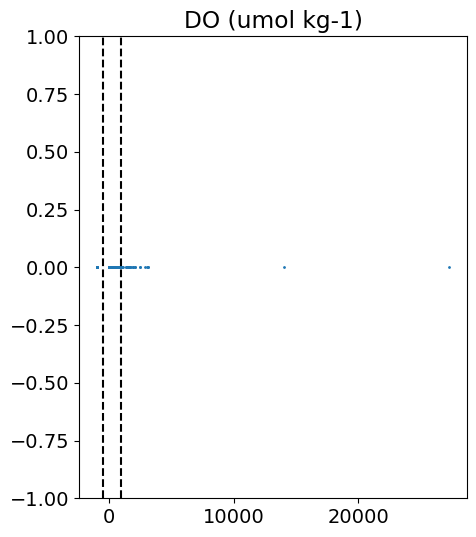

In [36]:
# lets see if there are any clear anomalies
test = 'DO (umol kg-1)'
fig, ax = plt.subplots(1,1, figsize = (5, 6))
ax.scatter(temp[test],temp['depth (m)'], s=1, label=test)

ax.set_title(test)

ax.set_ylim([-1,1])
# ax.set_xlim([0,5000])

l, r, _ = _stdev(temp, test)
ax.plot([l,l],[-1,1],'k--')
ax.plot([r,r],[-1,1],'k--')

In [37]:
# trim based on standard deviation 
temp[test] = qaqc_trim(temp, test)

# and add to df
ob = pd.concat([ob, temp])

In [38]:
ooi_nit = pd.read_pickle('/ocean/rbeutel/MOAD/analysis-becca/LiveOcean/tracers/observations/OOI_nitrate.p')
ooi_nit.head()

# add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(ooi_nit.datetime)
temp['longitude (degrees_east)'] = ooi_nit['longitude (degrees_east)']
temp['latitude (degrees_north)'] = ooi_nit['latitude (degrees_north)']
temp['pressure (dbar)'] = ooi_nit['z (m)']
temp['depth (m)'] = ooi_nit['z (m)']
temp['NO3 (uM)'] = ooi_nit['mole_concentration_of_nitrate_in_sea_water (micromol.L-1)']
temp['source'] ="ooi"

# make sure all columns are numeric
cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')


In [39]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO3 (uM)']),np.min(temp['NO3 (uM)']),np.mean(temp['NO3 (uM)'])))

max = 855.3548817981541, min = -48.81902652567501, mean = 30.593988041902637


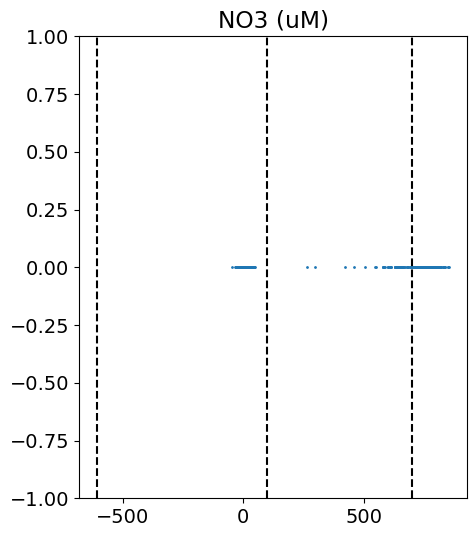

In [40]:
# lets see if there are any clear anomalies
test = 'NO3 (uM)'
fig, ax = plt.subplots(1,1, figsize = (5, 6))
ax.scatter(temp[test],temp['depth (m)'], s=1, label=test)

ax.set_title(test)

ax.set_ylim([-1,1])
# ax.set_xlim([0,5000])

l, r, _ = _stdev(temp, test)
ax.plot([l,l],[-1,1],'k--')
ax.plot([r,r],[-1,1],'k--')

# i think there much be something wrong or inconsistent in the units
# allegedly micromol per L BUT 500+ uM is craaaaaaaazy 
ax.plot([100,100],[-1,1],'k--')


In [41]:
# drop values greater than 100
temp['NO3 (uM)'][temp['NO3 (uM)']>100] = np.nan 

In [42]:
# trim based on standard deviation 
temp[test] = qaqc_trim(temp, test)

# and add to df
ob = pd.concat([ob, temp])

In [43]:
    tracer='NO3 (uM)'
    # Increase font size
    plt.rcParams['font.size'] = 14

    # Make plot area
    xlim, ylim = [-145.5, -120.2], [30, 60]
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
    ax.set_extent(xlim + ylim)

    # Draw coastline
    ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

    # Add gridlines
    xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
    gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.top_labels, gl.right_labels = False, False

# add points
ax.scatter(temp['longitude (degrees_east)'][~np.isnan(temp[tracer])], temp['latitude (degrees_north)'][~np.isnan(temp[tracer])], s=14, c='r', transform=crs.PlateCarree(),zorder=7)

IndentationError: unexpected indent (3240909534.py, line 1)

### ONC

In [44]:
onc = pd.read_pickle('/ocean/rbeutel/MOAD/analysis-becca/LiveOcean/tracers/observations/ONC.p')

# combine the two temperature columns together
onc['temperature (degC)'] = onc['temperature (K)'].fillna(0)+onc['Temperature (K)'].fillna(0) - 273
onc.drop(['temperature (K)','Temperature (K)','datetime'],axis=1,inplace=True)
onc.head()

# # convert to correct units
onc['SA'] = gsw.conversions.SA_from_SP(onc['salinity (1e-3)'],onc['depth (m)'],onc['longitude (degrees_east)'],onc['latitude (degrees_north)'])

# # # add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(onc.time)
temp['longitude (degrees_east)'] = onc['longitude (degrees_east)']
temp['latitude (degrees_north)'] = onc['latitude (degrees_north)']
temp['pressure (dbar)'] = onc['depth (m)']
temp['depth (m)'] = onc['depth (m)']
temp['temperature (degC)'] = onc['temperature (degC)']
temp['salinity (g kg-1)'] = onc['SA']
temp['source'] ="onc"

# make sure all columns are numeric
cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')

In [45]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))

max = 55.80224353239261, min = 0.009419033321140522, mean = 33.317502635937366
max = 22.481497938775476, min = 0.14999999999997726, mean = 7.389488635041315


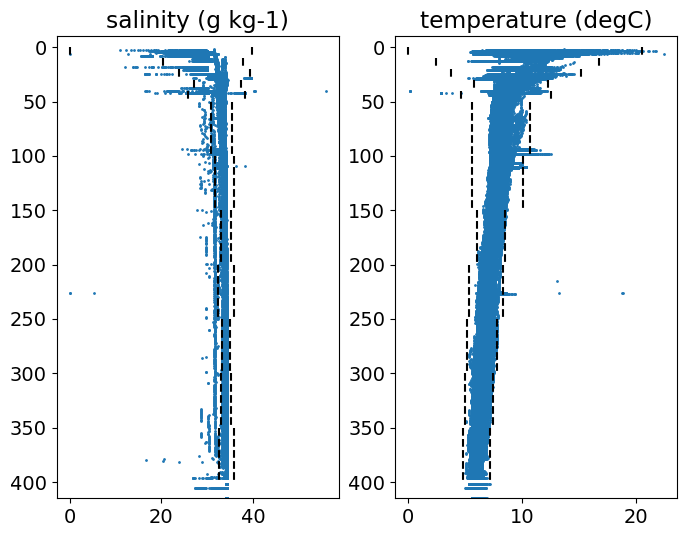

In [46]:
# lets see if there are any clear anomalies
test = ['salinity (g kg-1)', 'temperature (degC)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

In [47]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

# and add to df
ob = pd.concat([ob, temp])

In [48]:
    tracer = 'temperature (degC)'
    
    # Increase font size
    plt.rcParams['font.size'] = 14

    # Make plot area
    xlim, ylim = [-145.5, -120.2], [30, 60]
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
    ax.set_extent(xlim + ylim)

    # Draw coastline
    ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

    # Add gridlines
    xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
    gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.top_labels, gl.right_labels = False, False

# add points
ax.scatter(temp['longitude (degrees_east)'][~np.isnan(temp[tracer])], temp['latitude (degrees_north)'][~np.isnan(temp[tracer])], s=4, c='r', transform=crs.PlateCarree(),zorder=7)

IndentationError: unexpected indent (1644802508.py, line 1)

### Department of Ecology

In [49]:
# Initialize an empty list to store individual dataframes
dataframes = []
years = np.arange(1999,2023+1,1)

# Loop through the range of years
for year in years:
    # Construct the file path
    file_path = f'/data/rbeutel/obs/ecology_nc/bottle/{year}.p'
    
    # Read the pickled dataframe
    df = pd.read_pickle(file_path)
    
    # Append the dataframe to the list
    dataframes.append(df)

# Concatenate all the dataframes in the list into a single dataframe
ecob = pd.concat(dataframes, ignore_index=True)
ecob.head()

# convert to correct units
ecob['z'] = ecob['z']*-1
ecob['T'] = gsw.conversions.t_from_CT(ecob['SA'],ecob['CT'],ecob['z'])

# # # add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(ecob.time)
temp['longitude (degrees_east)'] = ecob['lon']
temp['latitude (degrees_north)'] = ecob['lat']
temp['pressure (dbar)'] = ecob['z']
temp['depth (m)'] = ecob['z']
temp['temperature (degC)'] = ecob['T']
temp['salinity (g kg-1)'] = ecob['SA']
temp['DO (umol kg-1)'] = oxygen_uM_to_umolkg(ecob['DO (uM)'],temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['Chl (mg m-3)'] = ecob['Chl (mg m-3)']
temp['NO3 (uM)'] = ecob['NO3 (uM)']
temp['NH4 (uM)'] = ecob['NH4 (uM)']
temp['PO4 (uM)'] = ecob['PO4 (uM)']
temp['SiO4 (uM)'] = ecob['SiO4 (uM)']
temp['source'] ="department of ecology"

cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')
# ob = pd.concat([ob, temp])

In [50]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['Chl (mg m-3)']),np.min(temp['Chl (mg m-3)']),np.mean(temp['Chl (mg m-3)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO3 (uM)']),np.min(temp['NO3 (uM)']),np.mean(temp['NO3 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['PO4 (uM)']),np.min(temp['PO4 (uM)']),np.mean(temp['PO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['SiO4 (uM)']),np.min(temp['SiO4 (uM)']),np.mean(temp['SiO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['NH4 (uM)']),np.min(temp['NH4 (uM)']),np.mean(temp['NH4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))


# pretty high max NO3 and SiO4

max = 167.40679931640625, min = -0.18549999594688416, mean = 3.8614385
max = 76.1500015258789, min = 0.0, mean = 18.357622
max = 6.239999771118164, min = 0.0, mean = 1.8968998
max = 302.9700012207031, min = 1.5399999618530273, mean = 51.50454
max = 104.0, min = 0.0, mean = 1.2148949
max = 33.682303984338944, min = 0.028033936852175912, mean = 28.329204054914964
max = 601.7366039330132, min = 6.8204487685542485, mean = 245.13844725728774
max = 23.99079918464234, min = 3.5862000022743845, mean = 10.917778856669997


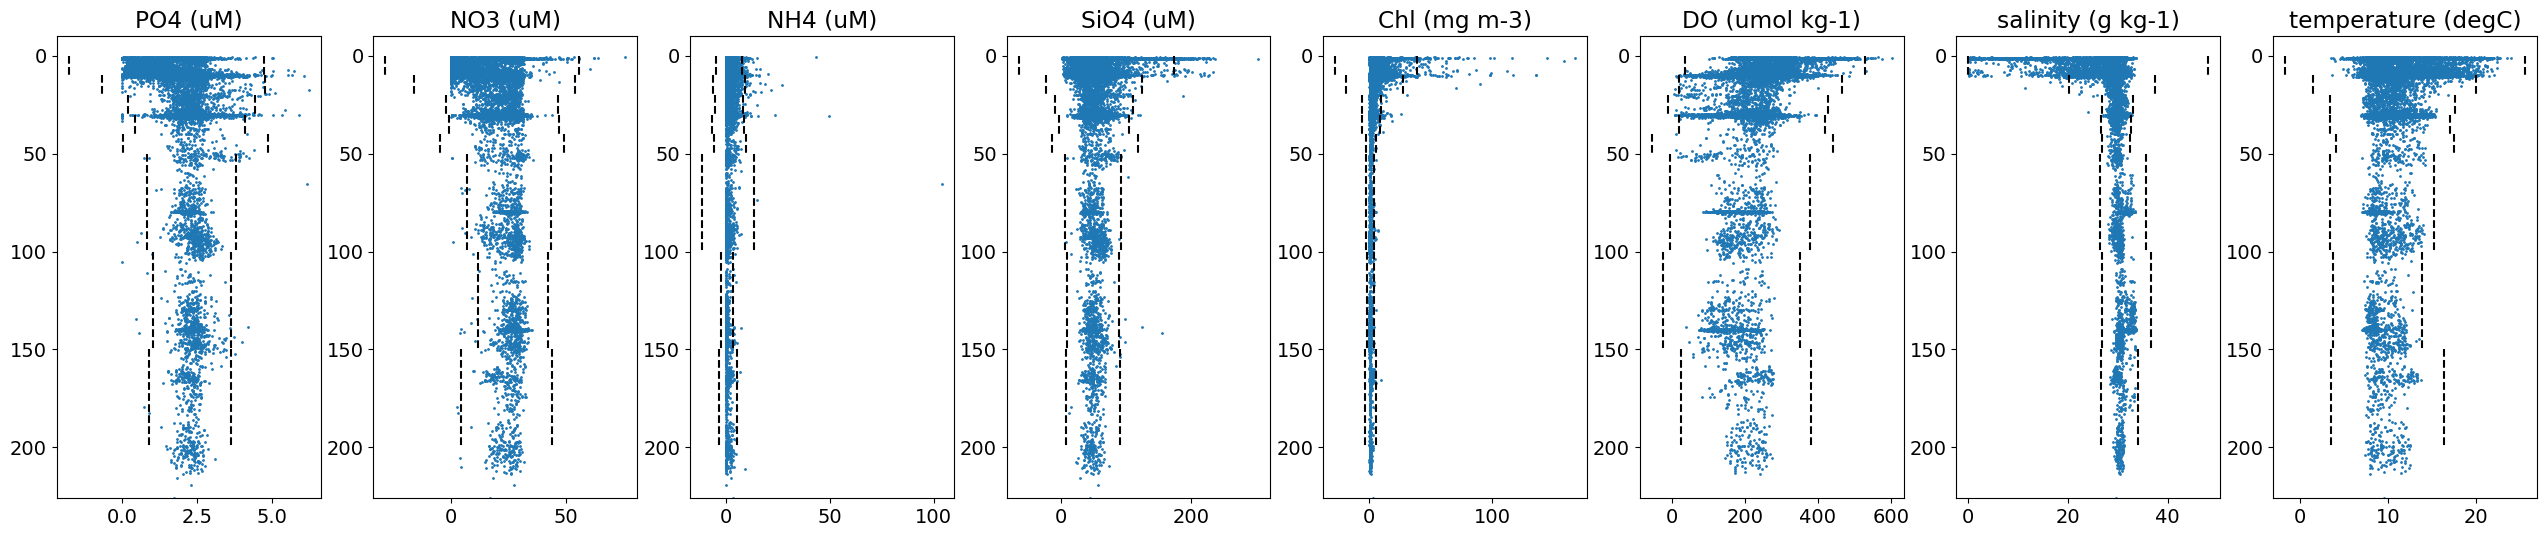

In [51]:
# lets see if there are any clear anomalies
test = ['PO4 (uM)', 'NO3 (uM)', 'NH4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)', 'DO (umol kg-1)','salinity (g kg-1)', 'temperature (degC)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])


In [52]:
    tracer = 'temperature (degC)'
    
    # Increase font size
    plt.rcParams['font.size'] = 14

    # Make plot area
    xlim, ylim = [-145.5, -120.2], [30, 60]
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
    ax.set_extent(xlim + ylim)

    # Draw coastline
    ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

    # Add gridlines
    xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
    gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.top_labels, gl.right_labels = False, False

# add points
ax.scatter(temp['longitude (degrees_east)'][~np.isnan(temp[tracer])], temp['latitude (degrees_north)'][~np.isnan(temp[tracer])], s=4, c='r', transform=crs.PlateCarree(),zorder=7)

IndentationError: unexpected indent (1644802508.py, line 1)

In [53]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

# GROUPING day and 1 m depth bins 
df = temp
df['longitude (degrees_east)'] = df['longitude (degrees_east)'].round(2)
df['latitude (degrees_north)'] = df['latitude (degrees_north)'].round(2)
df['depth (m)'] = df['depth (m)'].round(0)  # Round depth to the nearest meter
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.floor('D')  # Round time to the day

# Define a custom aggregation function
def aggregate_sources(series):
    return ', '.join(series.unique())
    
# Create an aggregation dictionary to apply 'mean' to numerical columns and the custom function for 'source'
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  # Select only numeric columns
aggregation_dict = {col: 'mean' for col in numeric_columns if col not in ['longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']}

# For non-numeric columns, such as 'source', use a custom aggregation function
aggregation_dict['source'] = aggregate_sources

# Group by time, longitude, latitude, and depth, then aggregate using the defined rules
grouped_df = df.groupby(['time', 'longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']).agg(aggregation_dict).reset_index()

# and add to df
ob = pd.concat([ob, grouped_df])

In [54]:
# Initialize an empty list to store individual dataframes
dataframes = []
years = np.arange(1999,2023+1,1)

# Loop through the range of years
for year in years:
    # Construct the file path
    file_path = f'/data/rbeutel/obs/ecology_nc/ctd/{year}.p'
    
    # Read the pickled dataframe
    df = pd.read_pickle(file_path)
    
    # Append the dataframe to the list
    dataframes.append(df)

# Concatenate all the dataframes in the list into a single dataframe
ecoc = pd.concat(dataframes, ignore_index=True)
ecoc.head()

# convert to correct units
ecoc['z'] = ecoc['z']*-1
ecoc['T'] = gsw.conversions.t_from_CT(ecoc['SA'],ecoc['CT'],ecoc['z'])

# add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(ecoc.time)
temp['longitude (degrees_east)'] = ecoc['lon']
temp['latitude (degrees_north)'] = ecoc['lat']
temp['pressure (dbar)'] = ecoc['z']
temp['depth (m)'] = ecoc['z']
temp['temperature (degC)'] = ecoc['T']
temp['salinity (g kg-1)'] = ecoc['SA']
temp['DO (umol kg-1)'] = oxygen_uM_to_umolkg(ecoc['DO (uM)'],temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['Chl (mg m-3)'] = ecoc['Chl (mg m-3)']

temp['source'] ="department of ecology"

cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')

In [55]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['Chl (mg m-3)']),np.min(temp['Chl (mg m-3)']),np.mean(temp['Chl (mg m-3)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))

max = 195.9257049560547, min = -0.39559999108314514, mean = 1.9467138
max = 33.879031137814096, min = 0.02331149285392424, mean = 29.93128549781064
max = 691.6954050292003, min = 0.0, mean = 213.22722112868718
max = 24.097097601406656, min = 3.012588957390299, mean = 10.101064377804713


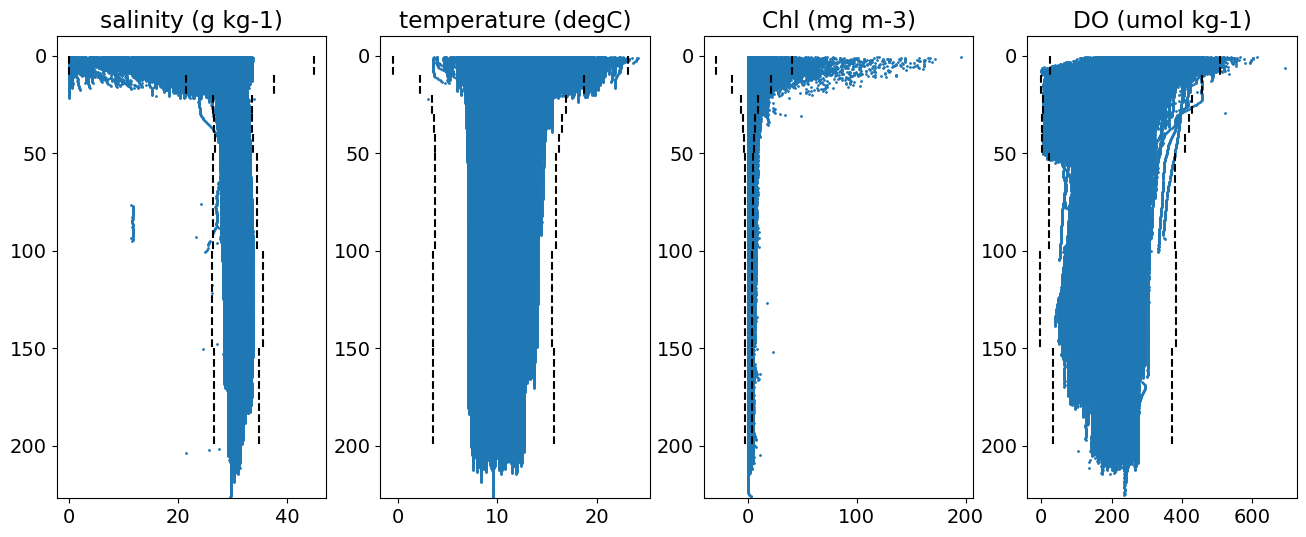

In [56]:
# lets see if there are any clear anomalies
test = ['salinity (g kg-1)', 'temperature (degC)', 'Chl (mg m-3)', 'DO (umol kg-1)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

In [57]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

# GROUPING day and 1 m depth bins 
df = temp
df['longitude (degrees_east)'] = df['longitude (degrees_east)'].round(2)
df['latitude (degrees_north)'] = df['latitude (degrees_north)'].round(2)
df['depth (m)'] = df['depth (m)'].round(0)  # Round depth to the nearest meter
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.floor('D')  # Round time to the day

# Define a custom aggregation function
def aggregate_sources(series):
    return ', '.join(series.unique())
    
# Create an aggregation dictionary to apply 'mean' to numerical columns and the custom function for 'source'
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  # Select only numeric columns
aggregation_dict = {col: 'mean' for col in numeric_columns if col not in ['longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']}

# For non-numeric columns, such as 'source', use a custom aggregation function
aggregation_dict['source'] = aggregate_sources

# Group by time, longitude, latitude, and depth, then aggregate using the defined rules
grouped_df = df.groupby(['time', 'longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']).agg(aggregation_dict).reset_index()

# and add to df
ob = pd.concat([ob, grouped_df])

In [58]:
    tracer = 'temperature (degC)'
    
    # Increase font size
    plt.rcParams['font.size'] = 14

    # Make plot area
    xlim, ylim = [-145.5, -120.2], [30, 60]
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
    ax.set_extent(xlim + ylim)

    # Draw coastline
    ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

    # Add gridlines
    xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
    gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.top_labels, gl.right_labels = False, False

# add points
ax.scatter(temp['longitude (degrees_east)'][~np.isnan(temp[tracer])], temp['latitude (degrees_north)'][~np.isnan(temp[tracer])], s=4, c='r', transform=crs.PlateCarree(),zorder=7)

IndentationError: unexpected indent (1644802508.py, line 1)

### NCEI
##### PNW

In [59]:
# Initialize an empty list to store individual dataframes
dataframes = []
years = [1985,1986,1989] + list(np.arange(1991,2008+1,1)) + [2010,2013,2014,2015,2016,2017]

# Loop through the range of years
for year in years:
    # Construct the file path
    file_path = f'/data/rbeutel/obs/nceiPNW/bottle/{year}.p'
    
    # Read the pickled dataframe
    df = pd.read_pickle(file_path)
    
    # Append the dataframe to the list
    dataframes.append(df)

# Concatenate all the dataframes in the list into a single dataframe
pncei = pd.concat(dataframes, ignore_index=True)
pncei.head()

# convert to correct units
pncei['z'] = pncei['z']*-1
pncei['T'] = gsw.conversions.t_from_CT(pncei['SA'],pncei['CT'],pncei['z'])

# add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(pncei.time)
temp['longitude (degrees_east)'] = pncei['lon']
temp['latitude (degrees_north)'] = pncei['lat']
temp['pressure (dbar)'] = pncei['z']
temp['depth (m)'] = pncei['z']
temp['temperature (degC)'] = pncei['T']
temp['salinity (g kg-1)'] = pncei['SA']
temp['DO (umol kg-1)'] = oxygen_uM_to_umolkg(pncei['DO (uM)'],temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['NO3 (uM)'] = pncei['NO3 (uM)']
temp['PO4 (uM)'] = pncei['PO4 (uM)']
temp['TA (uM)'] = pncei['TA (uM)']
temp['DIC (uM)'] = pncei['DIC (uM)']


temp['source'] ="NCEI PNW"

cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')

In [60]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO3 (uM)']),np.min(temp['NO3 (uM)']),np.mean(temp['NO3 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['PO4 (uM)']),np.min(temp['PO4 (uM)']),np.mean(temp['PO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['DIC (uM)']),np.min(temp['DIC (uM)']),np.mean(temp['DIC (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['TA (uM)']),np.min(temp['TA (uM)']),np.mean(temp['TA (uM)'])))

# reasonable range

max = 47.264142326819055, min = 0.0, mean = 24.110871017385605
max = 386.6000743393139, min = 4.400031861251784, mean = 155.09011741471102
max = 3.9307485547003274, min = 0.13137246505634434, mean = 1.915295901439517
max = 2493.5756556454735, min = 1754.7276853762448, mean = 2222.394070649411
max = 2516.4938292905335, min = 2023.0630359708514, mean = 2309.2242456454824


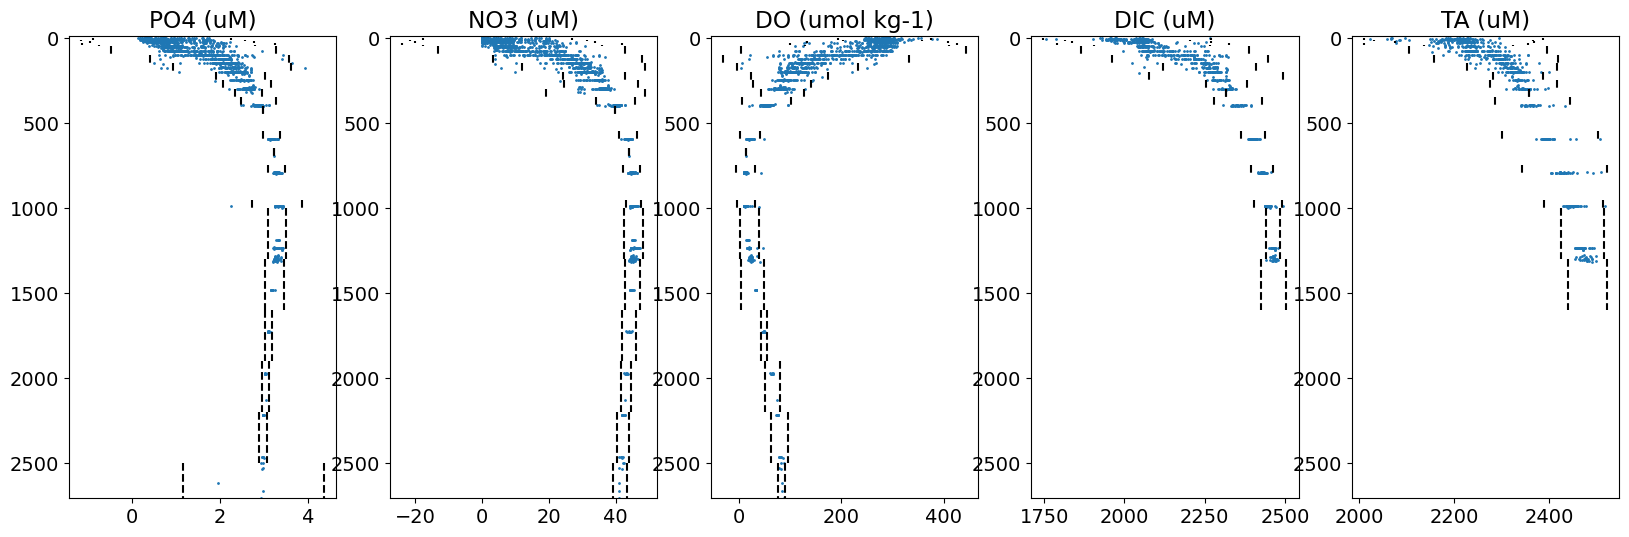

In [61]:
# lets see if there are any clear anomalies
test = ['PO4 (uM)', 'NO3 (uM)', 'DO (umol kg-1)', 'DIC (uM)', 'TA (uM)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

In [62]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

# GROUPING day and 1 m depth bins 
df = temp
df['longitude (degrees_east)'] = df['longitude (degrees_east)'].round(2)
df['latitude (degrees_north)'] = df['latitude (degrees_north)'].round(2)
df['depth (m)'] = df['depth (m)'].round(0)  # Round depth to the nearest meter
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.floor('D')  # Round time to the day

# Define a custom aggregation function
def aggregate_sources(series):
    return ', '.join(series.unique())
    
# Create an aggregation dictionary to apply 'mean' to numerical columns and the custom function for 'source'
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  # Select only numeric columns
aggregation_dict = {col: 'mean' for col in numeric_columns if col not in ['longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']}

# For non-numeric columns, such as 'source', use a custom aggregation function
aggregation_dict['source'] = aggregate_sources

# Group by time, longitude, latitude, and depth, then aggregate using the defined rules
grouped_df = df.groupby(['time', 'longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']).agg(aggregation_dict).reset_index()

# and add to ob
ob = pd.concat([ob, grouped_df])

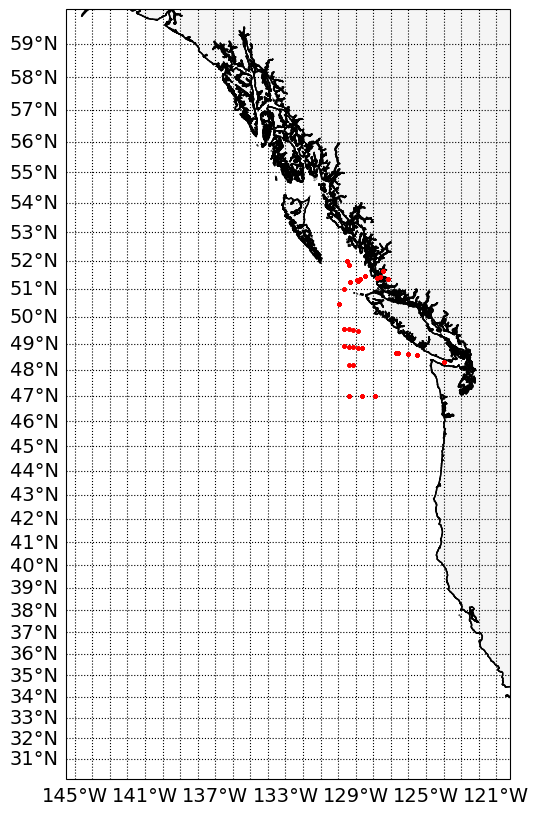

In [63]:
    tracer = 'temperature (degC)'

    # Increase font size
    plt.rcParams['font.size'] = 14

    # Make plot area
    xlim, ylim = [-145.5, -120.2], [30, 60]
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
    ax.set_extent(xlim + ylim)

    # Draw coastline
    ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

    # Add gridlines
    xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
    gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.top_labels, gl.right_labels = False, False

    # add points
    ax.scatter(temp['longitude (degrees_east)'][~np.isnan(temp[tracer])], temp['latitude (degrees_north)'][~np.isnan(temp[tracer])], s=4, c='r', transform=crs.PlateCarree(),zorder=7)  

##### Coastal

In [64]:
cncei = pd.read_csv('/data/rbeutel/obs/nceiCoastal/bottle/CODAP_NA_v2021.csv').drop(0)

# replace all -999 values with np.nan
cncei.replace(-999,np.nan, inplace=True)
cncei.replace('-999',np.nan, inplace=True)

# convert to correct units
cncei['SA'] = gsw.conversions.SA_from_SP(pd.to_numeric(cncei['recommended_Salinity_PSS78']),pd.to_numeric(cncei['CTDPRES']),pd.to_numeric(cncei['Longitude']),pd.to_numeric(cncei['Latitude']))

# add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = [dt.datetime(int(cncei.Year_UTC[i]), int(cncei.Month_UTC[i]), int(cncei.Day_UTC[i]), int(float(cncei.Time_UTC[i])*24)) for i in cncei.index]
temp['longitude (degrees_east)'] = pd.to_numeric(cncei['Longitude'])
temp['latitude (degrees_north)'] = pd.to_numeric(cncei['Latitude'])
temp['pressure (dbar)'] = pd.to_numeric(cncei['CTDPRES'])
temp['depth (m)'] = pd.to_numeric(cncei['Depth'])
temp['temperature (degC)'] = pd.to_numeric(cncei['CTDTEMP_ITS90'])
temp['salinity (g kg-1)'] = pd.to_numeric(cncei['SA'])
temp['DO (umol kg-1)'] = pd.to_numeric(cncei['recommended_Oxygen'])
temp['DIC (uM)'] = umolkg_to_uM(pd.to_numeric(cncei['DIC']), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['TA (uM)'] = umolkg_to_uM(pd.to_numeric(cncei['TALK']), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['Aragonite'] = umolkg_to_uM(pd.to_numeric(cncei['Aragonite']), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['Calcite'] = umolkg_to_uM(pd.to_numeric(cncei['Calcite']), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['Carbonate'] = umolkg_to_uM(pd.to_numeric(cncei['Carbonate_measured']), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['PO4 (uM)'] = umolkg_to_uM(pd.to_numeric(cncei['Phosphate']), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['SiO4 (uM)'] = umolkg_to_uM(pd.to_numeric(cncei['Silicate']), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['NO3 (uM)'] = umolkg_to_uM(pd.to_numeric(cncei['Nitrate']), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['NO2 (uM)'] = umolkg_to_uM(pd.to_numeric(cncei['Nitrite']), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['NH4 (uM)'] = umolkg_to_uM(pd.to_numeric(cncei['Ammonium']), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])

temp['source'] ="NCEI Coastal"

# make sure all columns are numeric
cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')

In [65]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO3 (uM)']),np.min(temp['NO3 (uM)']),np.mean(temp['NO3 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO2 (uM)']),np.min(temp['NO2 (uM)']),np.mean(temp['NO2 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['NH4 (uM)']),np.min(temp['NH4 (uM)']),np.mean(temp['NH4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['SiO4 (uM)']),np.min(temp['SiO4 (uM)']),np.mean(temp['SiO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['PO4 (uM)']),np.min(temp['PO4 (uM)']),np.mean(temp['PO4 (uM)'])))
print('\n')
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))
print('\n')
print('max = %s, min = %s, mean = %s' % (np.max(temp['DIC (uM)']),np.min(temp['DIC (uM)']),np.mean(temp['DIC (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['TA (uM)']),np.min(temp['TA (uM)']),np.mean(temp['TA (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['Aragonite']),np.min(temp['Aragonite']),np.mean(temp['Aragonite'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['Calcite']),np.min(temp['Calcite']),np.mean(temp['Calcite'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['Carbonate']),np.min(temp['Carbonate']),np.mean(temp['Carbonate'])))

# reasonable range

max = 52.69241726551367, min = 0.0, mean = 15.801771376116623
max = 3.843546946702109, min = 0.0, mean = 0.09628999335582725
max = 8.123459706691538, min = 0.0, mean = 0.597137161992794
max = 244.15428480121042, min = 0.0, mean = 24.963981310875713
max = 3.7563728720421024, min = 0.0, mean = 1.251882203248295


max = 495.1, min = 2.7, mean = 221.94482868659722
max = 37.78882076646747, min = 0.11755932458134012, mean = 33.47502312229022
max = 31.735, min = -1.786, mean = 10.325033743746229


max = 2677.0391409959716, min = 886.4977809107647, mean = 2158.799900768424
max = 2914.981125302041, min = 878.0968542866104, mean = 2307.985384270804
max = 5.198407808335352, min = 0.34360889794915456, mean = 1.750681879053829
max = 7.817997625476893, min = 0.5861563553250283, mean = 2.727653732243221
max = 303.9941733007874, min = 39.65803057042441, mean = 135.37686575795482


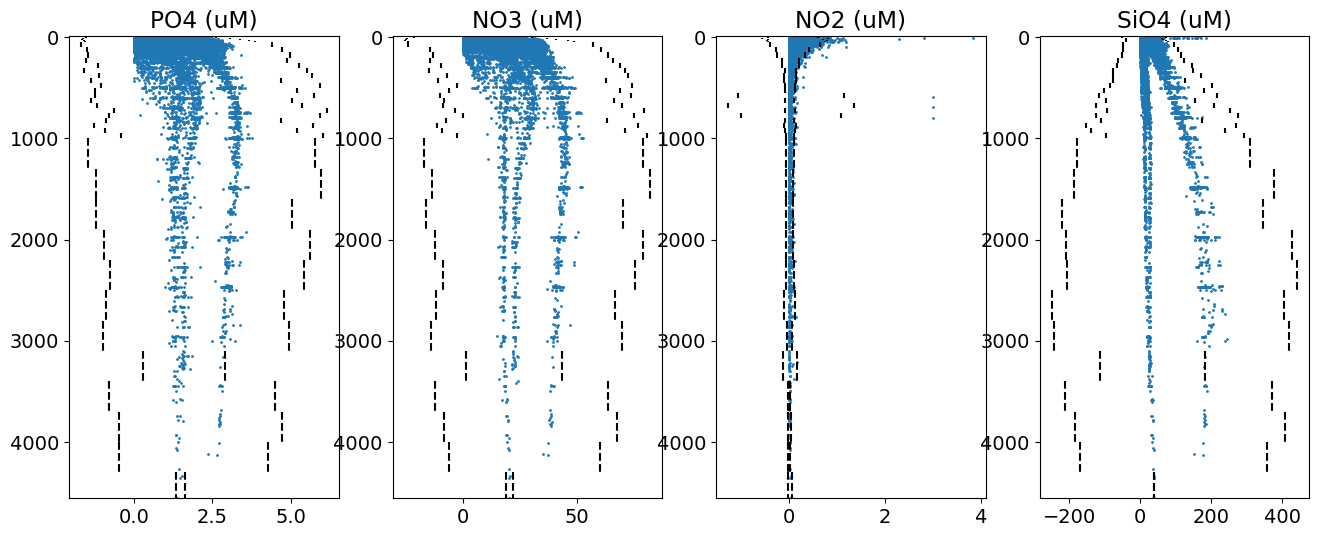

In [66]:
# lets see if there are any clear anomalies
test = ['PO4 (uM)', 'NO3 (uM)', 'NO2 (uM)', 'SiO4 (uM)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

In [67]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

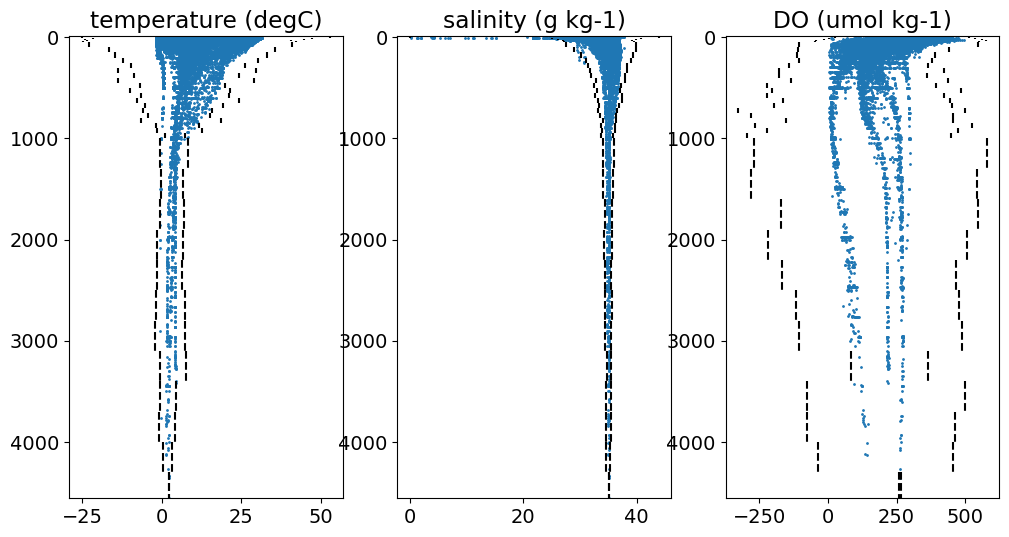

In [68]:
# lets see if there are any clear anomalies
test = ['temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

In [69]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

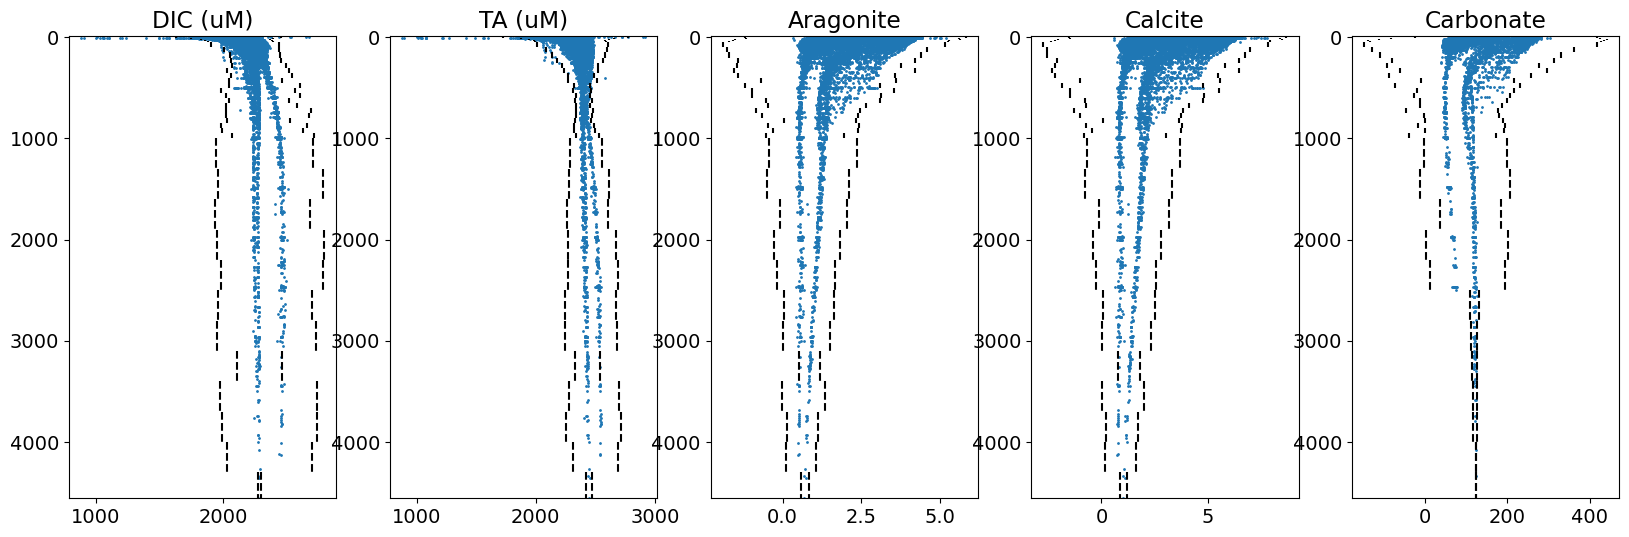

In [70]:
# lets see if there are any clear anomalies
test = ['DIC (uM)', 'TA (uM)', 'Aragonite', 'Calcite', 'Carbonate']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

In [71]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

In [72]:
# GROUPING day and 1 m depth bins 
df = temp
df['longitude (degrees_east)'] = df['longitude (degrees_east)'].round(2)
df['latitude (degrees_north)'] = df['latitude (degrees_north)'].round(2)
df['depth (m)'] = df['depth (m)'].round(0)  # Round depth to the nearest meter
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.floor('D')  # Round time to the day

# Define a custom aggregation function
def aggregate_sources(series):
    return ', '.join(series.unique())
    
# Create an aggregation dictionary to apply 'mean' to numerical columns and the custom function for 'source'
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  # Select only numeric columns
aggregation_dict = {col: 'mean' for col in numeric_columns if col not in ['longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']}

# For non-numeric columns, such as 'source', use a custom aggregation function
aggregation_dict['source'] = aggregate_sources

# Group by time, longitude, latitude, and depth, then aggregate using the defined rules
grouped_df = df.groupby(['time', 'longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']).agg(aggregation_dict).reset_index()

# and add to ob
ob = pd.concat([ob, grouped_df])

In [73]:
    tracer = 'temperature (degC)'
    
    # Increase font size
    plt.rcParams['font.size'] = 14

    # Make plot area
    xlim, ylim = [-145.5, -120.2], [30, 60]
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
    ax.set_extent(xlim + ylim)

    # Draw coastline
    ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

    # Add gridlines
    xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
    gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.top_labels, gl.right_labels = False, False

# add points
ax.scatter(temp['longitude (degrees_east)'][~np.isnan(temp[tracer])], temp['latitude (degrees_north)'][~np.isnan(temp[tracer])], s=4, c='r', transform=crs.PlateCarree(),zorder=7)

IndentationError: unexpected indent (1644802508.py, line 1)

### Salish

In [74]:
sncei = pd.read_csv('/ocean/ksuchy/MOAD/observe/SalishCruise_dataProduct_2008to2018_09202023_allData.csv')#.drop(0)

# replace all -999 values with np.nan
sncei.replace(-999,np.nan, inplace=True)
sncei.replace('-999',np.nan, inplace=True)

# convert to correct units
sncei['SA'] = gsw.conversions.SA_from_SP(pd.to_numeric(sncei['CTDSAL_PSS78']),pd.to_numeric(sncei['CTDPRS_DBAR']),pd.to_numeric(sncei['LONGITUDE_DEC']),pd.to_numeric(sncei['LATITUDE_DEC']))

# add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(sncei.DATE_UTC) # fine to jsut bring in the day since we are going to bin by day later anyways
temp['longitude (degrees_east)'] = pd.to_numeric(sncei['LONGITUDE_DEC'])
temp['latitude (degrees_north)'] = pd.to_numeric(sncei['LATITUDE_DEC'])
temp['pressure (dbar)'] = pd.to_numeric(sncei['CTDPRS_DBAR'])
temp['depth (m)'] = pd.to_numeric(sncei['CTDPRS_DBAR'])
temp['temperature (degC)'] = pd.to_numeric(sncei['CTDTMP_DEG_C_ITS90'])
temp['salinity (g kg-1)'] = pd.to_numeric(sncei['SA'])
temp['DO (umol kg-1)'] = pd.to_numeric(sncei['RECOMMENDED_OXYGEN_UMOL_KG'])
temp['DIC (uM)'] = umolkg_to_uM(pd.to_numeric(sncei['DIC_UMOL_KG']), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['TA (uM)'] = umolkg_to_uM(pd.to_numeric(sncei['TA_UMOL_KG']), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['PO4 (uM)'] = pd.to_numeric(sncei['PHOSPHATE_UMOL_L'])
temp['SiO4 (uM)'] = pd.to_numeric(sncei['SILICATE_UMOL_L'])
temp['NO3 (uM)'] = pd.to_numeric(sncei['NITRATE_UMOL_L'])
temp['NO2 (uM)'] = pd.to_numeric(sncei['NITRITE_UMOL_L'])
temp['NH4 (uM)'] = pd.to_numeric(sncei['AMMONIUM_UMOL_L'])

temp['source'] ="NCEI Salish"

# make sure all columns are numeric
cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')

In [75]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO3 (uM)']),np.min(temp['NO3 (uM)']),np.mean(temp['NO3 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO2 (uM)']),np.min(temp['NO2 (uM)']),np.mean(temp['NO2 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['NH4 (uM)']),np.min(temp['NH4 (uM)']),np.mean(temp['NH4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['SiO4 (uM)']),np.min(temp['SiO4 (uM)']),np.mean(temp['SiO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['PO4 (uM)']),np.min(temp['PO4 (uM)']),np.mean(temp['PO4 (uM)'])))
print('\n')
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))
print('\n')
print('max = %s, min = %s, mean = %s' % (np.max(temp['DIC (uM)']),np.min(temp['DIC (uM)']),np.mean(temp['DIC (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['TA (uM)']),np.min(temp['TA (uM)']),np.mean(temp['TA (uM)'])))

# reasonable range

max = 39.94, min = 0.0, mean = 20.897898491973407
max = 2.27, min = -0.01, mean = 0.3044275056762893
max = 9.96, min = -0.01, mean = 0.7941186962866872
max = 115.2, min = 1.07, mean = 46.92133149529679
max = 5.23, min = 0.03, mean = 2.1309194097616344


max = 492.0, min = 8.9, mean = 202.71985626829917
max = 34.15764829387036, min = 15.35094763358231, mean = 30.16080449348597
max = 21.8239, min = 5.966, mean = 10.87010158139535


max = 2426.742931267979, min = 1087.8709760895374, mean = 2061.1735971287726
max = 2357.3814677877485, min = 1290.3715889215503, mean = 2126.8853282276355


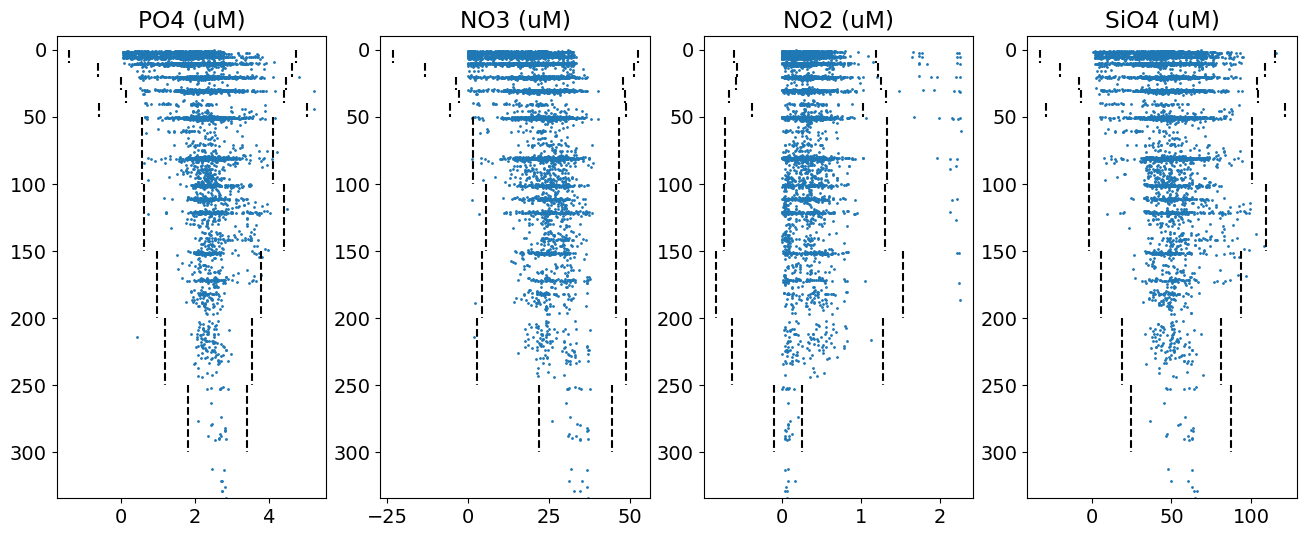

In [76]:
# lets see if there are any clear anomalies
test = ['PO4 (uM)', 'NO3 (uM)', 'NO2 (uM)', 'SiO4 (uM)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

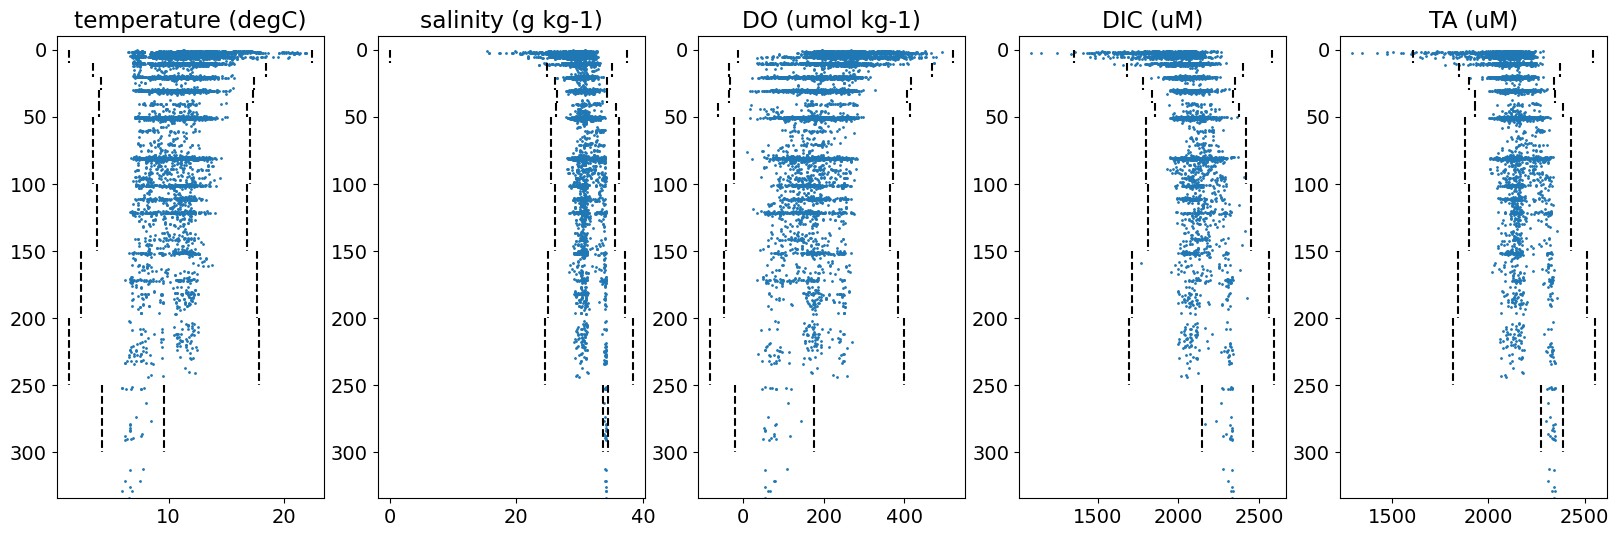

In [77]:
# lets see if there are any clear anomalies
test = ['temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'DIC (uM)', 'TA (uM)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

In [78]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

In [79]:
# GROUPING day and 1 m depth bins 
df = temp
df['longitude (degrees_east)'] = df['longitude (degrees_east)'].round(2)
df['latitude (degrees_north)'] = df['latitude (degrees_north)'].round(2)
df['depth (m)'] = df['depth (m)'].round(0)  # Round depth to the nearest meter
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.floor('D')  # Round time to the day

# Define a custom aggregation function
def aggregate_sources(series):
    return ', '.join(series.unique())
    
# Create an aggregation dictionary to apply 'mean' to numerical columns and the custom function for 'source'
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  # Select only numeric columns
aggregation_dict = {col: 'mean' for col in numeric_columns if col not in ['longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']}

# For non-numeric columns, such as 'source', use a custom aggregation function
aggregation_dict['source'] = aggregate_sources

# Group by time, longitude, latitude, and depth, then aggregate using the defined rules
grouped_df = df.groupby(['time', 'longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']).agg(aggregation_dict).reset_index()

# and add to ob
ob = pd.concat([ob, grouped_df])

In [80]:
    tracer = 'temperature (degC)'
    
    # Increase font size
    plt.rcParams['font.size'] = 14

    # Make plot area
    xlim, ylim = [-145.5, -120.2], [30, 60]
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
    ax.set_extent(xlim + ylim)

    # Draw coastline
    ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

    # Add gridlines
    xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
    gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.top_labels, gl.right_labels = False, False

# add points
ax.scatter(temp['longitude (degrees_east)'][~np.isnan(temp[tracer])], temp['latitude (degrees_north)'][~np.isnan(temp[tracer])], s=4, c='r', transform=crs.PlateCarree(),zorder=7)

IndentationError: unexpected indent (1644802508.py, line 1)

### OCNMS

In [81]:
# Initialize an empty list to store individual dataframes
dataframes = []
years = np.arange(2004,2023+1,1)

# Loop through the range of years
for year in years:
    # Construct the file path
    file_path = f'/data/rbeutel/obs/ocnms_ctd/ctd/{year}.p'
    
    # Read the pickled dataframe
    df = pd.read_pickle(file_path)
    
    # Append the dataframe to the list
    dataframes.append(df)

# Concatenate all the dataframes in the list into a single dataframe
ocnms = pd.concat(dataframes, ignore_index=True)
ocnms.head()

# convert to correct units
ocnms['z'] = ocnms['z']*-1
ocnms['T'] = gsw.conversions.t_from_CT(ocnms['SA'],ocnms['CT'],ocnms['z'])

# add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(ocnms.time)
temp['longitude (degrees_east)'] = ocnms['lon']
temp['latitude (degrees_north)'] = ocnms['lat']
temp['pressure (dbar)'] = ocnms['z']
temp['depth (m)'] = ocnms['z']
temp['temperature (degC)'] = ocnms['T']
temp['salinity (g kg-1)'] = ocnms['SA']
temp['DO (umol kg-1)'] = oxygen_uM_to_umolkg(ocnms['DO (uM)'],temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])

temp['source'] ="OCNMS"

# make sure all columns are numeric
cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')

In [82]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))
# reasonable range

max = 553.6882568733622, min = 3.769996092471353, mean = 183.1026673324749
max = 35.25347736508091, min = 18.098472601032462, mean = 32.84035376423034
max = 17.7995964531052, min = 6.471335431385989, mean = 9.727172440443072


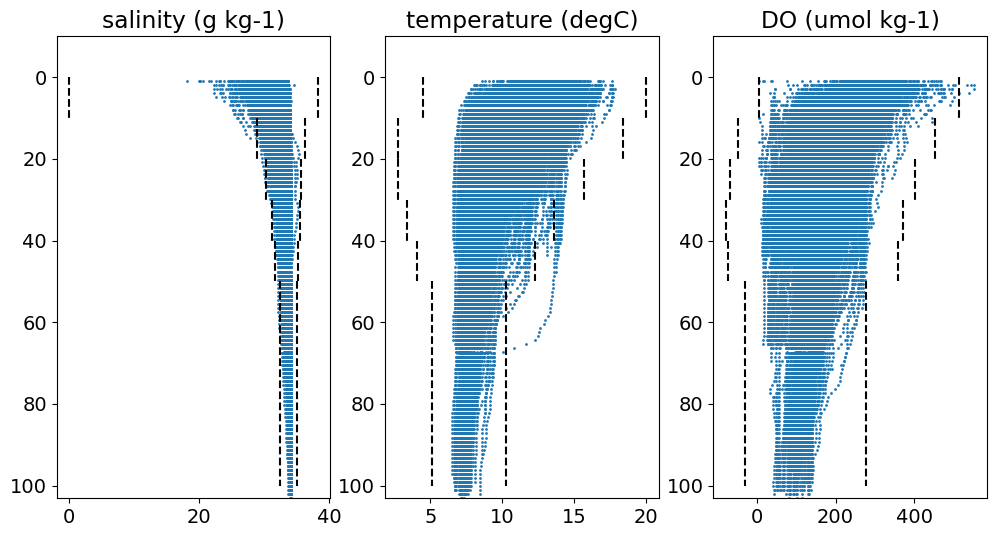

In [83]:
# lets see if there are any clear anomalies
test = ['salinity (g kg-1)', 'temperature (degC)', 'DO (umol kg-1)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

In [84]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

# GROUPING day and 1 m depth bins 
df = temp
df['longitude (degrees_east)'] = df['longitude (degrees_east)'].round(2)
df['latitude (degrees_north)'] = df['latitude (degrees_north)'].round(2)
df['depth (m)'] = df['depth (m)'].round(0)  # Round depth to the nearest meter
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.floor('D')  # Round time to the day

# Define a custom aggregation function
def aggregate_sources(series):
    return ', '.join(series.unique())
    
# Create an aggregation dictionary to apply 'mean' to numerical columns and the custom function for 'source'
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  # Select only numeric columns
aggregation_dict = {col: 'mean' for col in numeric_columns if col not in ['longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']}

# For non-numeric columns, such as 'source', use a custom aggregation function
aggregation_dict['source'] = aggregate_sources

# Group by time, longitude, latitude, and depth, then aggregate using the defined rules
grouped_df = df.groupby(['time', 'longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']).agg(aggregation_dict).reset_index()

# and add to ob
ob = pd.concat([ob, grouped_df])

In [85]:
    tracer = 'temperature (degC)'
    
    # Increase font size
    plt.rcParams['font.size'] = 14

    # Make plot area
    xlim, ylim = [-145.5, -120.2], [30, 60]
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
    ax.set_extent(xlim + ylim)

    # Draw coastline
    ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

    # Add gridlines
    xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
    gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.top_labels, gl.right_labels = False, False

# add points
ax.scatter(temp['longitude (degrees_east)'][~np.isnan(temp[tracer])], temp['latitude (degrees_north)'][~np.isnan(temp[tracer])], s=4, c='r', transform=crs.PlateCarree(),zorder=7)

IndentationError: unexpected indent (1644802508.py, line 1)

### NHL

In [96]:
# Initialize an empty list to store individual dataframes
dataframes = []
years = np.arange(1997,2021+1,1)

# Loop through the range of years
for year in years:
    # Construct the file path
    file_path = f'/data/rbeutel/obs/NHL/ctd/{year}.csv'
    
    # Read the pickled dataframe
    df = pd.read_csv(file_path)
    
    # Append the dataframe to the list
    dataframes.append(df)

# Concatenate all the dataframes in the list into a single dataframe
nhl = pd.concat(dataframes, ignore_index=True)

# drop -9999 values
nhl.replace(-9999, np.nan, inplace=True)

nhl.head()

# convert to correct units
nhl['DO'] = oxygen_mlL_to_umolkg(nhl['DO (ml/L)'], nhl['temperature (degC)'], nhl.salinity, nhl['pressure (dbar)'])

print(nhl[nhl['datetime'] == "2005-09-29"])

# add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime(nhl.datetime, errors='coerce')
temp['longitude (degrees_east)'] = nhl['lon']
temp['latitude (degrees_north)'] = nhl['lat']
temp['pressure (dbar)'] = nhl['pressure (dbar)']
temp['depth (m)'] = nhl['pressure (dbar)']
temp['temperature (degC)'] = nhl['temperature (degC)']
temp['salinity (g kg-1)'] = nhl['salinity']
temp['DO (umol kg-1)'] = nhl['DO']

temp['source'] ="NHL"

# make sure all columns are numeric
cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')

          datetime     lat     lon  station_name  pressure (dbar)  \
311259  2005-09-29  44.652 -124.18             5              2.0   
311260  2005-09-29  44.652 -124.18             5              3.0   
311261  2005-09-29  44.652 -124.18             5              4.0   
311262  2005-09-29  44.652 -124.18             5              5.0   
311263  2005-09-29  44.652 -124.18             5              6.0   
...            ...     ...     ...           ...              ...   
311606  2005-09-29  44.652 -124.53            20            134.0   
311607  2005-09-29  44.652 -124.53            20            135.0   
311608  2005-09-29  44.652 -124.53            20            136.0   
311609  2005-09-29  44.652 -124.53            20            137.0   
311610  2005-09-29  44.652 -124.53            20            138.0   

        temperature (degC)  salinity  DO (ml/L) cruise          DO  
311259              8.5916    33.745     3.3126     NH  144.179643  
311260              8.5708    33.

In [97]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))

max = 523.6457173818494, min = -0.8659436520163492, mean = 128.17958729179375
max = 65.888, min = 15.712, mean = 33.49337818745838
max = 19.656, min = 1.7193, mean = 7.791337495409166


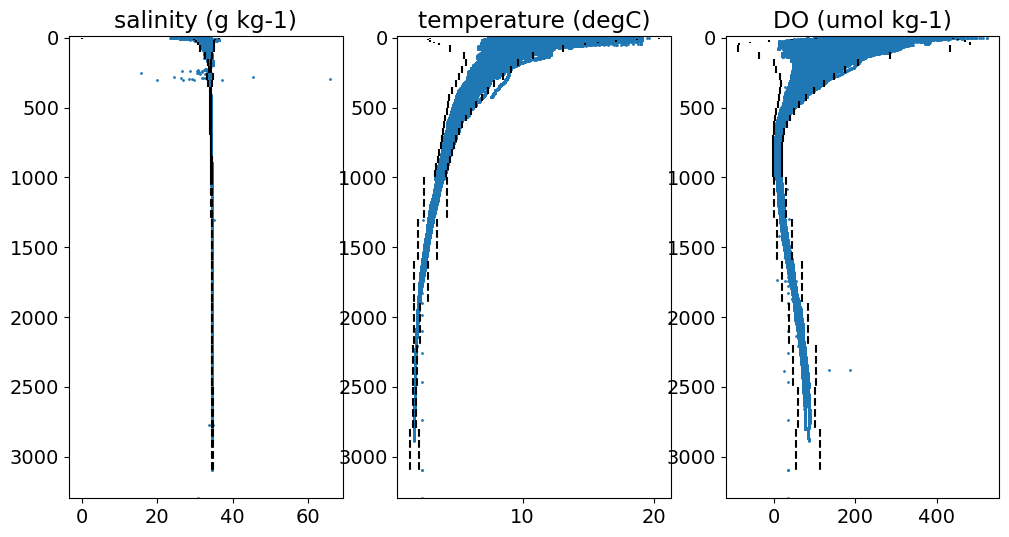

In [98]:
# lets see if there are any clear anomalies
test = ['salinity (g kg-1)', 'temperature (degC)', 'DO (umol kg-1)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

In [99]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

# GROUPING day and 1 m depth bins 
df = temp
df['longitude (degrees_east)'] = df['longitude (degrees_east)'].round(2)
df['latitude (degrees_north)'] = df['latitude (degrees_north)'].round(2)
df['depth (m)'] = df['depth (m)'].round(0)  # Round depth to the nearest meter
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.floor('D')  # Round time to the day

# Define a custom aggregation function
def aggregate_sources(series):
    return ', '.join(series.unique())
    
# Create an aggregation dictionary to apply 'mean' to numerical columns and the custom function for 'source'
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  # Select only numeric columns
aggregation_dict = {col: 'mean' for col in numeric_columns if col not in ['longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']}

# For non-numeric columns, such as 'source', use a custom aggregation function
aggregation_dict['source'] = aggregate_sources

# Group by time, longitude, latitude, and depth, then aggregate using the defined rules
grouped_df = df.groupby(['time', 'longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']).agg(aggregation_dict).reset_index()

# and add to ob
ob = pd.concat([ob, grouped_df])

In [100]:
    tracer = 'temperature (degC)'
    
    # Increase font size
    plt.rcParams['font.size'] = 14

    # Make plot area
    xlim, ylim = [-145.5, -120.2], [30, 60]
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
    ax.set_extent(xlim + ylim)

    # Draw coastline
    ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

    # Add gridlines
    xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
    gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.top_labels, gl.right_labels = False, False

# add points
ax.scatter(temp['longitude (degrees_east)'][~np.isnan(temp[tracer])], temp['latitude (degrees_north)'][~np.isnan(temp[tracer])], s=4, c='r', transform=crs.PlateCarree(),zorder=7)

IndentationError: unexpected indent (1644802508.py, line 1)

### GEOTRACES

In [101]:
geo = xr.open_dataset("/ocean/rbeutel/MOAD/analysis-becca/LiveOcean/tracers/GEOTRACES/data_from_GEOTRACES_IDP2021_Seawater_Discrete_Sample_Data_v2.nc")

In [102]:
temp = pd.DataFrame(d)

# ok so if we flatten a single variable it looks like 52 arrays of length 290 lined up therefore we should make the variable descrition as follows:
temp['time'] = np.repeat(geo.date_time.values,290)
temp['longitude (degrees_east)'] = np.repeat(geo.longitude.values,290)
temp['latitude (degrees_north)'] = np.repeat(geo.latitude.values,290)
temp['depth (m)'] = geo.DEPTH.values.flatten()
temp['pressure (dbar)'] = geo.CTDPRS_T_VALUE_SENSOR.values.flatten()
temp['temperature (degC)'] = geo.CTDTMP_T_VALUE_SENSOR.values.flatten()
temp['salinity (g kg-1)'] = gsw.conversions.SA_from_SP(geo.SALINITY_D_CONC_BOTTLE.values.flatten(), temp['pressure (dbar)'].values, temp['longitude (degrees_east)'].values, temp['latitude (degrees_north)'].values) # convert to SA
temp['DO (umol kg-1)'] = geo.OXYGEN_D_CONC_BOTTLE.values.flatten()
temp['NO3 (uM)'] = umolkg_to_uM(geo.NITRATE_D_CONC_BOTTLE.values.flatten(), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['NO2 (uM)'] = umolkg_to_uM(geo.NITRITE_D_CONC_BOTTLE.values.flatten(), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['PO4 (uM)'] = umolkg_to_uM(geo.PHOSPHATE_D_CONC_BOTTLE.values.flatten(), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['SiO4 (uM)'] = umolkg_to_uM(geo.SILICATE_D_CONC_BOTTLE.values.flatten(), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)'])
temp['Cd (nmol kg-1)'] = umolkg_to_uM(geo.Cd_D_CONC_BOTTLE.values.flatten(), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)']) 
temp['Co (nmol kg-1)'] = umolkg_to_uM(geo.Co_D_CONC_BOTTLE.values.flatten(), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)']) 
temp['Cu (nmol kg-1)'] = umolkg_to_uM(geo.Cu_D_CONC_BOTTLE.values.flatten(), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)']) 
temp['Fe (nmol kg-1)'] = umolkg_to_uM(geo.Fe_D_CONC_BOTTLE.values.flatten(), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)']) 
temp['Mn (nmol kg-1)'] = umolkg_to_uM(geo.Mn_D_CONC_BOTTLE.values.flatten(), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)']) 
temp['Ni (nmol kg-1)'] = umolkg_to_uM(geo.Ni_D_CONC_BOTTLE.values.flatten(), temp['temperature (degC)'], temp['salinity (g kg-1)'], temp['pressure (dbar)']) 

temp['source'] = 'GEOTRACES'

# make sure all columns are numeric
cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')

In [103]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO3 (uM)']),np.min(temp['NO3 (uM)']),np.mean(temp['NO3 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO2 (uM)']),np.min(temp['NO2 (uM)']),np.mean(temp['NO2 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['PO4 (uM)']),np.min(temp['PO4 (uM)']),np.mean(temp['PO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['SiO4 (uM)']),np.min(temp['SiO4 (uM)']),np.mean(temp['SiO4 (uM)'])))
print('\n')
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))


max = 46.44782664605971, min = 0.0, mean = 30.419846776520416
max = 1.2520667789536497, min = -0.010416786297975116, mean = 0.03949914573029284
max = 3.895634539552322, min = 0.0, mean = 2.2378305742368694
max = 186.6235275404942, min = 0.0, mean = 97.70855623866744


max = 319.5, min = 6.78000020980835, mean = 144.41164
max = 35.34079810231484, min = 31.563615554596467, mean = 34.1567823076596
max = 26.5718994140625, min = 1.4239000082015991, mean = 6.025363


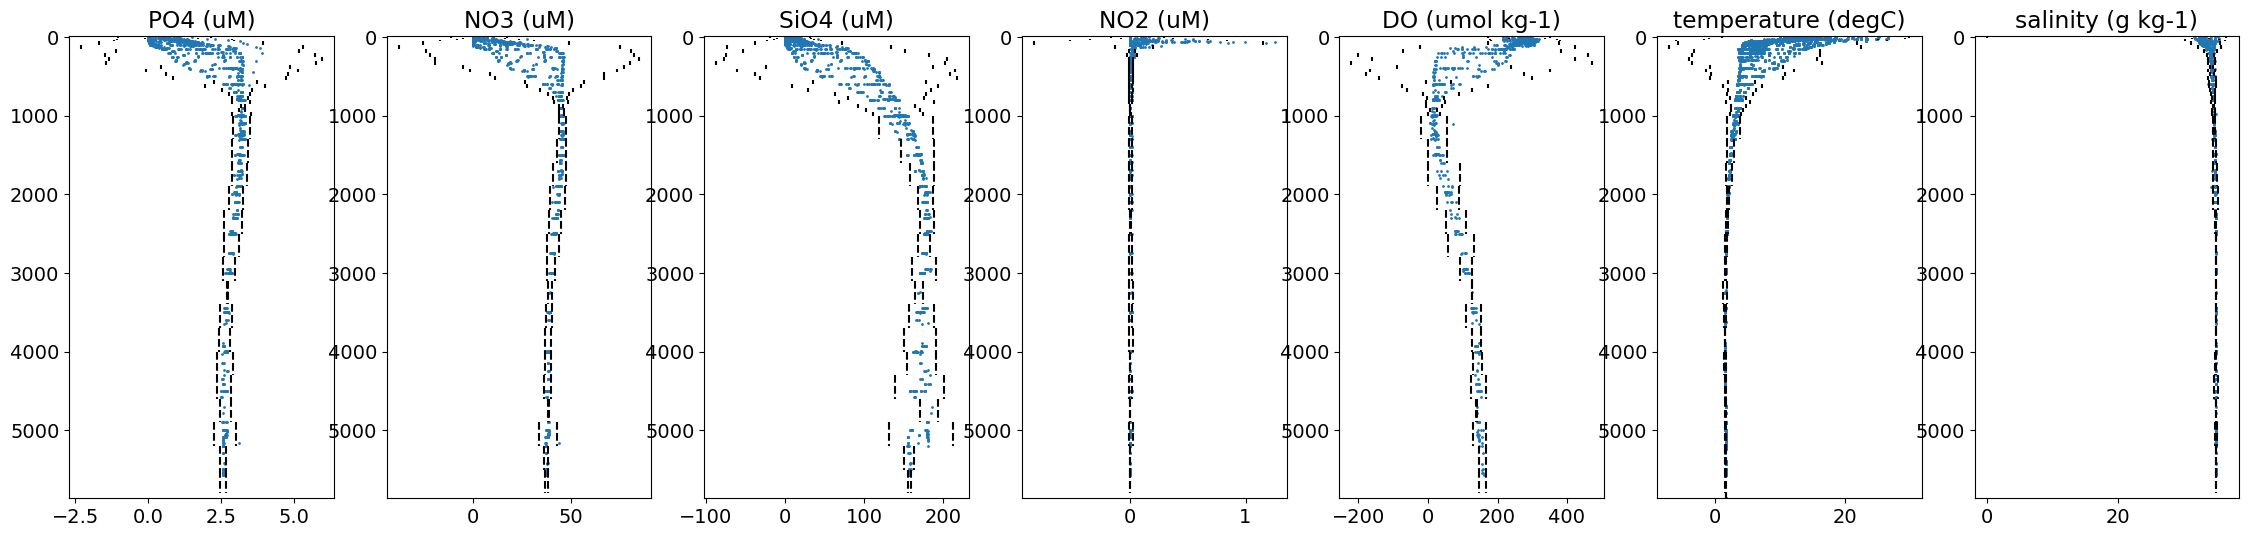

In [104]:
# lets see if there are any clear anomalies
test = ['PO4 (uM)', 'NO3 (uM)', 'SiO4 (uM)', 'NO2 (uM)', 'DO (umol kg-1)', 'temperature (degC)', 'salinity (g kg-1)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

In [105]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

# GROUPING day and 1 m depth bins 
df = temp
df['longitude (degrees_east)'] = df['longitude (degrees_east)'].round(2)
df['latitude (degrees_north)'] = df['latitude (degrees_north)'].round(2)
df['depth (m)'] = df['depth (m)'].round(0)  # Round depth to the nearest meter
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.floor('D')  # Round time to the day

# Define a custom aggregation function
def aggregate_sources(series):
    return ', '.join(series.unique())
    
# Create an aggregation dictionary to apply 'mean' to numerical columns and the custom function for 'source'
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  # Select only numeric columns
aggregation_dict = {col: 'mean' for col in numeric_columns if col not in ['longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']}

# For non-numeric columns, such as 'source', use a custom aggregation function
aggregation_dict['source'] = aggregate_sources

# Group by time, longitude, latitude, and depth, then aggregate using the defined rules
grouped_df = df.groupby(['time', 'longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']).agg(aggregation_dict).reset_index()

# and add to ob
ob = pd.concat([ob, grouped_df])

In [106]:
    tracer = 'Cd (nmol kg-1)'

    # Increase font size
    plt.rcParams['font.size'] = 14

    # Make plot area
    xlim, ylim = [-145.5, -120.2], [30, 60]
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
    ax.set_extent(xlim + ylim)

    # Draw coastline
    ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

    # Add gridlines
    xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
    gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.top_labels, gl.right_labels = False, False

# add points
ax.scatter(temp['longitude (degrees_east)'], temp['latitude (degrees_north)'], s=4, c='r', transform=crs.PlateCarree(),zorder=7)

IndentationError: unexpected indent (2511688168.py, line 1)

In [107]:
lp = pd.read_csv("/ocean/rbeutel/MOAD/analysis-becca/LiveOcean/tracers/GEOTRACES/TM_LineP_2012-2020_RobynTaves.csv").drop([0], axis=0).reset_index().drop(['index'], axis=1)
lp

# convert to correct units
# add to the dataframe
temp = pd.DataFrame(d)

temp['time'] = pd.to_datetime([lp['Start Date (UTC)'][i] +' '+lp['Start Time (UTC)'][i]  for i in lp.index])
temp['longitude (degrees_east)'] = lp['Start Longitude']
temp['latitude (degrees_north)'] = lp['Start Latitude']
temp['pressure (dbar)'] = lp['Depth']
temp['depth (m)'] = lp['Depth']
temp['Mn (nmol kg-1)'] = lp['Mn_D_CONC_BOTTLE']
temp['Fe (nmol kg-1)'] = lp['Fe_D_CONC_BOTTLE']
temp['Co (nmol kg-1)'] = lp['Co_D_CONC_BOTTLE']
temp['Ni (nmol kg-1)'] = lp['Ni_D_CONC_BOTTLE']
temp['Cu (nmol kg-1)'] = lp['Cu_D_CONC_BOTTLE']
temp['Zn (nmol kg-1)'] = lp['Zn_D_CONC_BOTTLE']
temp['Cd (nmol kg-1)'] = lp['Cd_D_CONC_BOTTLE']
# consider adding sigma to the dataset

temp['source'] ="GEOTRACES"

# make sure all columns are numeric
cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')

# GROUPING day and 1 m depth bins 
df = temp
df['longitude (degrees_east)'] = df['longitude (degrees_east)'].round(2)
df['latitude (degrees_north)'] = df['latitude (degrees_north)'].round(2)
df['depth (m)'] = df['depth (m)'].round(0)  # Round depth to the nearest meter
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.floor('D')  # Round time to the day

# Define a custom aggregation function
def aggregate_sources(series):
    return ', '.join(series.unique())
    
# Create an aggregation dictionary to apply 'mean' to numerical columns and the custom function for 'source'
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  # Select only numeric columns
aggregation_dict = {col: 'mean' for col in numeric_columns if col not in ['longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']}

# For non-numeric columns, such as 'source', use a custom aggregation function
aggregation_dict['source'] = aggregate_sources

# Group by time, longitude, latitude, and depth, then aggregate using the defined rules
grouped_df = df.groupby(['time', 'longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']).agg(aggregation_dict).reset_index()

# and add to ob
ob = pd.concat([ob, grouped_df])

ob = pd.concat([ob, temp])

### CALCOFI

In [108]:
dpath = "/ocean/ghoeven/MOAD/Data/CalCOFI_Database_194903-202105_csv_16October2023/CalCOFI_Database_194903-202105_csv_16October2023/"
bpath = dpath + "194903-202105_Bottle.csv"
cpath = dpath + "194903-202105_Cast.csv"

calBottle = pd.read_csv(bpath, encoding='latin1')
calCast   = pd.read_csv(cpath, encoding='latin1')

In [109]:
# Subset calCast to only the columns you want to bring in
metadata_cols = ['Cst_Cnt', 'Date', 'Time', 'Lon_Dec', 'Lat_Dec']
subset_cast = calCast[metadata_cols]

# Perform the merge of metadata from calCast onto raw data from calBottle
md = pd.merge(calBottle, subset_cast, on='Cst_Cnt', how='right')

md = md[md['Depthm'] <= 500] # remove depths below 500m
md = md[md['Date'].str[-4:].astype(int) > 1983] # remove data before 1984

# Create temp dataframe to subsitute the right columns from CALCOFI data
temp = pd.DataFrame(d)

temp['time'] = md["Date"] + ' ' + md["Time"]
temp['longitude (degrees_east)'] = md["Lon_Dec"]
temp['latitude (degrees_north)'] = md["Lat_Dec"]
temp['depth (m)'] = md["Depthm"]
temp['pressure (dbar)'] = gsw.conversions.p_from_z(-md["Depthm"], temp['latitude (degrees_north)'])
temp['temperature (degC)'] = md["T_degC"]
temp['salinity (g kg-1)'] = gsw.conversions.SA_from_SP(md["Salnty"], temp['pressure (dbar)'],temp['longitude (degrees_east)'] , temp['latitude (degrees_north)'])
temp['DO (umol kg-1)'] = md["Oxy_µmol/Kg"]
temp['NO3 (uM)'] = md['NO3uM']
temp['NO2 (uM)'] = md['NO2uM']
temp['PO4 (uM)'] = md['PO4uM']
#temp['SiO4 (uM)'] = md[]
#temp['Cd (nmol kg-1)'] = 
#temp['Co (nmol kg-1)'] = 
#temp['Cu (nmol kg-1)'] = 
#temp['Fe (nmol kg-1)'] = 
#temp['Mn (nmol kg-1)'] = 
#temp['Ni (nmol kg-1)'] = 

temp['source'] = 'CALCOFI'


# Make sure the columns are numeric
cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
temp[cols] = temp[cols].apply(pd.to_numeric, errors='coerce')

In [110]:
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO3 (uM)']),np.min(temp['NO3 (uM)']),np.mean(temp['NO3 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['NO2 (uM)']),np.min(temp['NO2 (uM)']),np.mean(temp['NO2 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['PO4 (uM)']),np.min(temp['PO4 (uM)']),np.mean(temp['PO4 (uM)'])))
print('\n')
print('max = %s, min = %s, mean = %s' % (np.max(temp['DO (umol kg-1)']),np.min(temp['DO (umol kg-1)']),np.mean(temp['DO (umol kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['salinity (g kg-1)']),np.min(temp['salinity (g kg-1)']),np.mean(temp['salinity (g kg-1)'])))
print('max = %s, min = %s, mean = %s' % (np.max(temp['temperature (degC)']),np.min(temp['temperature (degC)']),np.mean(temp['temperature (degC)'])))

max = 47.5, min = -0.4, mean = 16.285557344344895
max = 5.31, min = 0.0, mean = 0.041573351936054825
max = 4.39, min = 0.0, mean = 1.4084191918687994


max = 485.7018, min = -8740.57, mean = 168.33750994982805
max = 37.20942968050417, min = 9.5459107101738, mean = 33.815877275711635
max = 99.0, min = 4.69, mean = 11.38295804180743


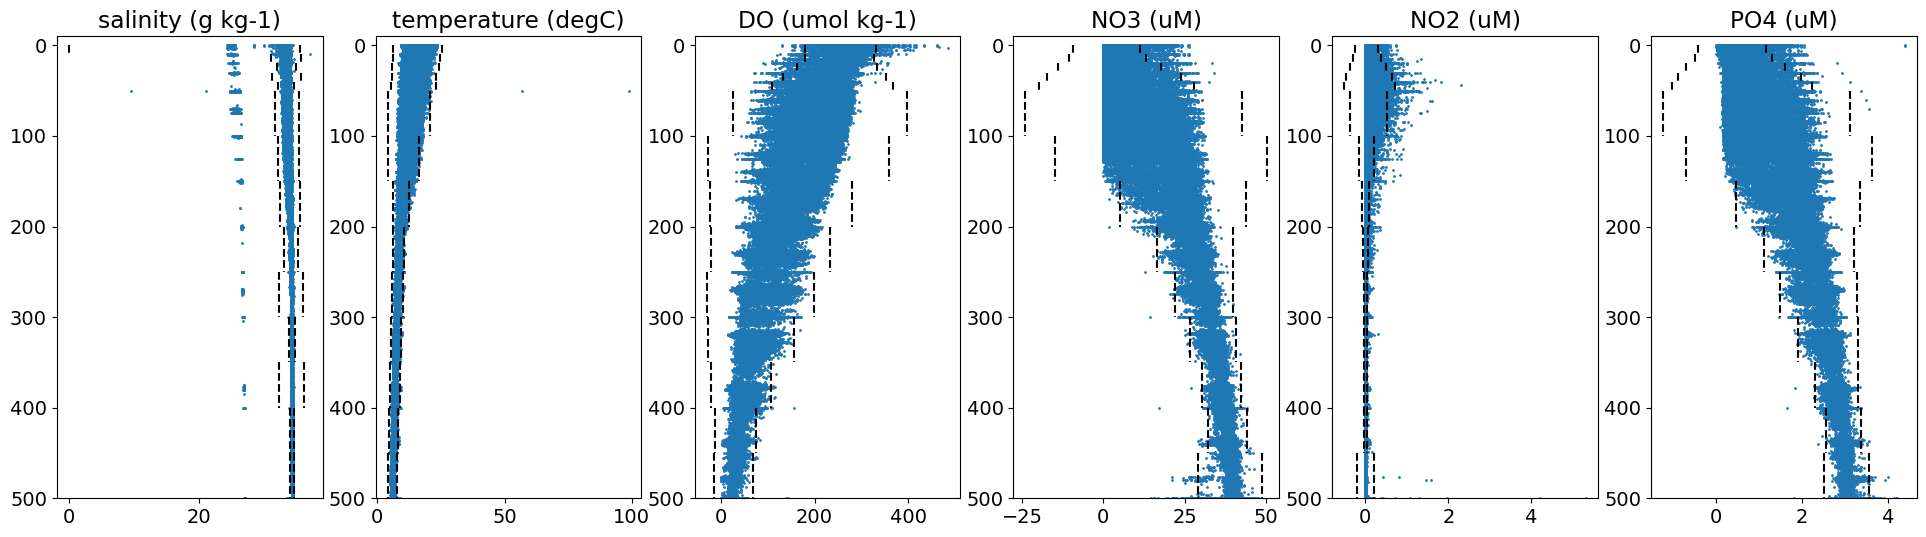

In [111]:
# lets see if there are any clear anomalies
test = ['salinity (g kg-1)', 'temperature (degC)', 'DO (umol kg-1)', 'NO3 (uM)', 'NO2 (uM)', 'PO4 (uM)']
fig, ax = plt.subplots(1,len(test), figsize = (len(test)*4, 6))

for i in range(len(test)):
    qaqc_plot(temp, test[i], ax[i])

In [112]:
# trim based on standard deviation 
for i in range(len(test)):
    temp[test[i]] = qaqc_trim(temp, test[i])

# GROUPING day and 1 m depth bins 
df = temp
df['longitude (degrees_east)'] = df['longitude (degrees_east)'].round(2)
df['latitude (degrees_north)'] = df['latitude (degrees_north)'].round(2)
df['depth (m)'] = df['depth (m)'].round(0)  # Round depth to the nearest meter
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.floor('D')  # Round time to the day

# Define a custom aggregation function
def aggregate_sources(series):
    return ', '.join(series.unique())
    
# Create an aggregation dictionary to apply 'mean' to numerical columns and the custom function for 'source'
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  # Select only numeric columns
aggregation_dict = {col: 'mean' for col in numeric_columns if col not in ['longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']}

# For non-numeric columns, such as 'source', use a custom aggregation function
aggregation_dict['source'] = aggregate_sources

# Group by time, longitude, latitude, and depth, then aggregate using the defined rules
grouped_df = df.groupby(['time', 'longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']).agg(aggregation_dict).reset_index()

# and add to ob
ob = pd.concat([ob, grouped_df])

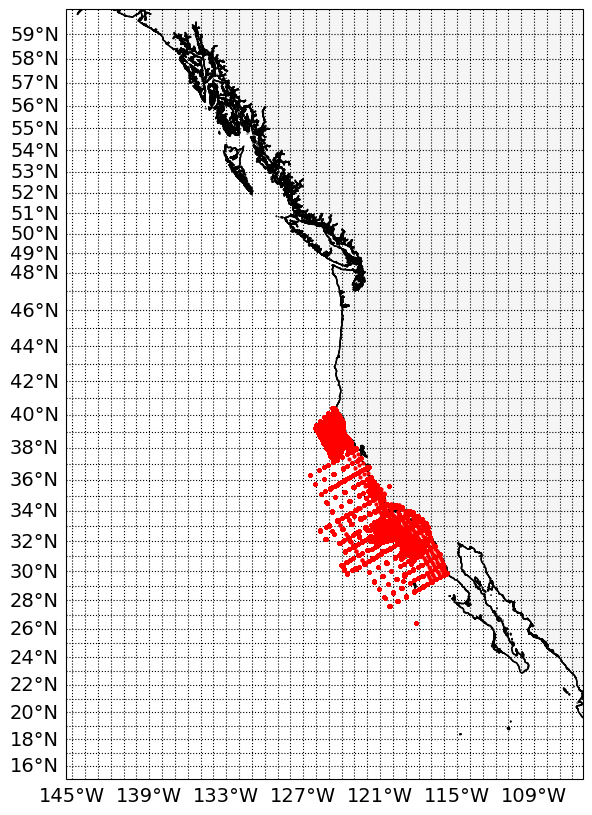

In [113]:
tracer = 'temperature (degC)'

# Increase font size
plt.rcParams['font.size'] = 14

# Make plot area
xlim, ylim = [-145.5, -105.2], [15, 60]
fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
ax.set_extent(xlim + ylim)

# Draw coastline
ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

# Add gridlines
xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
gl.top_labels, gl.right_labels = False, False

# add points
ax.scatter(temp['longitude (degrees_east)'][~np.isnan(temp[tracer])], temp['latitude (degrees_north)'][~np.isnan(temp[tracer])], s=4, c='r', transform=crs.PlateCarree(),zorder=7)

## Remove Repetition
Based on datetime (within one hour), depth, lat, lon

In [114]:
ob.columns

Index(['time', 'source', 'longitude (degrees_east)',
       'latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)'],
      dtype='object')

In [115]:
ob['time'] = pd.to_datetime(ob.time, utc=True)

# double checking that all columns are numeric
cols = ['longitude (degrees_east)','latitude (degrees_north)', 'depth (m)', 'pressure (dbar)',
       'temperature (degC)', 'salinity (g kg-1)', 'DO (umol kg-1)', 'NO3 (uM)',
       'NO2 (uM)', 'NH4 (uM)', 'PO4 (uM)', 'SiO4 (uM)', 'Chl (mg m-3)',
       'TA (uM)', 'DIC (uM)', 'Carbonate', 'Aragonite', 'Calcite',
       'Cd (nmol kg-1)', 'Co (nmol kg-1)', 'Cu (nmol kg-1)', 'Fe (nmol kg-1)',
       'Mn (nmol kg-1)', 'Ni (nmol kg-1)', 'Zn (nmol kg-1)']
ob[cols] = ob[cols].apply(pd.to_numeric, errors='coerce')

ob

,time,source,longitude (degrees_east),latitude (degrees_north),depth (m),pressure (dbar),temperature (degC),salinity (g kg-1),DO (umol kg-1),NO3 (uM),...,Carbonate,Aragonite,Calcite,Cd (nmol kg-1),Co (nmol kg-1),Cu (nmol kg-1),Fe (nmol kg-1),Mn (nmol kg-1),Ni (nmol kg-1),Zn (nmol kg-1)
0,2008-11-19 00:00:00+00:00,ios mooring,-123.42445,49.027150,13.064797,13.177000,9.5504,28.578352,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,2008-11-13 00:00:00+00:00,ios mooring,-126.20380,48.529415,33.900998,34.192333,NaN,32.367911,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
264,2008-11-14 00:00:00+00:00,ios mooring,-126.20380,48.529415,33.846801,34.137667,NaN,32.370080,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
265,2008-11-15 00:00:00+00:00,ios mooring,-126.20380,48.529415,33.887704,34.178923,NaN,32.368916,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266,2008-11-16 00:00:00+00:00,ios mooring,-126.20380,48.529415,33.844159,34.135000,NaN,32.367200,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321332,2021-05-13 00:00:00+00:00,CALCOFI,-119.41000,34.220000,10.000000,10.072284,16.5620,NaN,267.89,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
321333,2021-05-13 00:00:00+00:00,CALCOFI,-119.41000,34.220000,11.000000,11.079540,16.4050,NaN,271.63,0.220,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
321334,2021-05-13 00:00:00+00:00,CALCOFI,-119.41000,34.220000,20.000000,20.145061,15.8500,NaN,267.41,1.745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
321335,2021-05-13 00:00:00+00:00,CALCOFI,-119.41000,34.220000,29.000000,29.210982,13.2120,NaN,215.92,6.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
# sometimes things go wrong with CTDs.. so remove rows if salinity, temperature, or DO are acting crazy
ob.drop(ob.loc[ob['salinity (g kg-1)']>50].index, inplace=True)
ob.drop(ob.loc[ob['salinity (g kg-1)']<0].index, inplace=True)

ob.drop(ob.loc[ob['temperature (degC)']>40].index, inplace=True)
ob.drop(ob.loc[ob['temperature (degC)']<-3].index, inplace=True)

# otherwise if something's fishy, we dont want to drop the whole row but we also dont want to work with that value
ob['DO (umol kg-1)'][ob['DO (umol kg-1)']<0] = np.nan
ob['NO3 (uM)'][ob['NO3 (uM)']<0] = np.nan
ob['NO2 (uM)'][ob['NO2 (uM)']<0] = np.nan
ob['NH4 (uM)'][ob['NH4 (uM)']<0] = np.nan
ob['PO4 (uM)'][ob['PO4 (uM)']<0] = np.nan
ob['SiO4 (uM)'][ob['SiO4 (uM)']<0] = np.nan
ob['DIC (uM)'][ob['DIC (uM)']<0] = np.nan
ob['TA (uM)'][ob['TA (uM)']<0] = np.nan
ob['Chl (mg m-3)'][ob['Chl (mg m-3)']<0] = np.nan
ob['Carbonate'][ob['Carbonate']<0] = np.nan
ob['Aragonite'][ob['Aragonite']<0] = np.nan
ob['Calcite'][ob['Calcite']<0] = np.nan
ob['Cd (nmol kg-1)'][ob['Cd (nmol kg-1)']<0] = np.nan
ob['Co (nmol kg-1)'][ob['Co (nmol kg-1)']<0] = np.nan
ob['Cu (nmol kg-1)'][ob['Cu (nmol kg-1)']<0] = np.nan
ob['Fe (nmol kg-1)'][ob['Fe (nmol kg-1)']<0] = np.nan
ob['Mn (nmol kg-1)'][ob['Mn (nmol kg-1)']<0] = np.nan
ob['Ni (nmol kg-1)'][ob['Ni (nmol kg-1)']<0] = np.nan
ob['Zn (nmol kg-1)'][ob['Zn (nmol kg-1)']<0] = np.nan


In [117]:
# ok lets check some of the values we're having problems with
print('max = %s, min = %s, mean = %s' % (np.max(ob['NO3 (uM)']),np.min(ob['NO3 (uM)']),np.mean(ob['NO3 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(ob['PO4 (uM)']),np.min(ob['PO4 (uM)']),np.mean(ob['PO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(ob['SiO4 (uM)']),np.min(ob['SiO4 (uM)']),np.mean(ob['SiO4 (uM)'])))
print('max = %s, min = %s, mean = %s' % (np.max(ob['Chl (mg m-3)']),np.min(ob['Chl (mg m-3)']),np.mean(ob['Chl (mg m-3)'])))
print('max = %s, min = %s, mean = %s' % (np.max(ob['DO (umol kg-1)']),np.min(ob['DO (umol kg-1)']),np.mean(ob['DO (umol kg-1)'])))

max = 61.2, min = 0.0, mean = 17.140008885185726
max = 13.3, min = 0.0, mean = 1.5183405835801282
max = 244.15428480121042, min = 0.0, mean = 36.55163613988366
max = 47.1056, min = 0.0, mean = 1.9165902160860868
max = 920.8683559344508, min = 0.0, mean = 167.01974730619602


In [118]:
df = ob
df['longitude (degrees_east)'] = df['longitude (degrees_east)'].round(2)
df['latitude (degrees_north)'] = df['latitude (degrees_north)'].round(2)
df['depth (m)'] = df['depth (m)'].round(0)  # Round depth to the nearest meter
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.floor('D')  # Round time to nearest hour
 
# Define a custom aggregation function
def aggregate_sources(series):
    return ', '.join(series.unique())
    
# Create an aggregation dictionary to apply 'mean' to numerical columns and the custom function for 'source'
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  # Select only numeric columns
aggregation_dict = {col: 'mean' for col in numeric_columns if col not in ['longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']}

# For non-numeric columns, such as 'source', use a custom aggregation function
aggregation_dict['source'] = aggregate_sources

# Group by time, longitude, latitude, and depth, then aggregate using the defined rules
grouped_df = df.groupby(['time', 'longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)']).agg(aggregation_dict).reset_index()



In [119]:
grouped_df

,time,longitude (degrees_east),latitude (degrees_north),depth (m),pressure (dbar),temperature (degC),salinity (g kg-1),DO (umol kg-1),NO3 (uM),NO2 (uM),...,Aragonite,Calcite,Cd (nmol kg-1),Co (nmol kg-1),Cu (nmol kg-1),Fe (nmol kg-1),Mn (nmol kg-1),Ni (nmol kg-1),Zn (nmol kg-1),source
0,1930-11-07 00:00:00+00:00,-123.77,49.25,0.0,0.000000,NaN,28.462251,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ios bottle
1,1930-11-07 00:00:00+00:00,-123.77,49.25,1.0,1.008579,NaN,28.643227,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ios bottle
2,1930-11-07 00:00:00+00:00,-123.77,49.25,2.0,2.017163,NaN,28.552657,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ios bottle
3,1930-11-07 00:00:00+00:00,-123.77,49.25,4.0,4.034345,NaN,28.612890,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ios bottle
4,1930-11-07 00:00:00+00:00,-123.77,49.25,6.0,6.051547,NaN,29.387187,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ios bottle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657136,2024-11-19 00:00:00+00:00,-130.32,54.32,11.0,11.000000,9.064078,27.049797,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,onc
2657137,2024-11-19 00:00:00+00:00,-129.25,53.42,65.0,65.000000,9.565688,31.505568,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,onc
2657138,2024-11-19 00:00:00+00:00,-128.66,53.98,41.0,41.000000,9.694405,30.605699,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,onc
2657139,2024-11-19 00:00:00+00:00,-125.24,50.02,8.0,8.000000,9.853995,22.757943,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,onc


In [120]:
set(grouped_df.source)

{'CALCOFI',
 'GEOTRACES',
 'NCEI Coastal',
 'NCEI Coastal, NHL',
 'NCEI PNW',
 'NCEI Salish',
 'NHL',
 'OCNMS',
 'department of ecology',
 'department of ecology, NCEI Salish',
 'ios bottle',
 'ios bottle, GEOTRACES',
 'ios bottle, NCEI PNW',
 'ios bottle, NCEI PNW, GEOTRACES',
 'ios ctd profiles',
 'ios ctd profiles, ios bottle',
 'ios mooring',
 'ios mooring, ios bottle',
 'onc',
 'ooi'}

### Plot distribution of observations for each tracer

In [121]:
ob = grouped_df

In [122]:
ob

,time,longitude (degrees_east),latitude (degrees_north),depth (m),pressure (dbar),temperature (degC),salinity (g kg-1),DO (umol kg-1),NO3 (uM),NO2 (uM),...,Aragonite,Calcite,Cd (nmol kg-1),Co (nmol kg-1),Cu (nmol kg-1),Fe (nmol kg-1),Mn (nmol kg-1),Ni (nmol kg-1),Zn (nmol kg-1),source
0,1930-11-07 00:00:00+00:00,-123.77,49.25,0.0,0.000000,NaN,28.462251,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ios bottle
1,1930-11-07 00:00:00+00:00,-123.77,49.25,1.0,1.008579,NaN,28.643227,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ios bottle
2,1930-11-07 00:00:00+00:00,-123.77,49.25,2.0,2.017163,NaN,28.552657,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ios bottle
3,1930-11-07 00:00:00+00:00,-123.77,49.25,4.0,4.034345,NaN,28.612890,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ios bottle
4,1930-11-07 00:00:00+00:00,-123.77,49.25,6.0,6.051547,NaN,29.387187,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ios bottle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657136,2024-11-19 00:00:00+00:00,-130.32,54.32,11.0,11.000000,9.064078,27.049797,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,onc
2657137,2024-11-19 00:00:00+00:00,-129.25,53.42,65.0,65.000000,9.565688,31.505568,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,onc
2657138,2024-11-19 00:00:00+00:00,-128.66,53.98,41.0,41.000000,9.694405,30.605699,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,onc
2657139,2024-11-19 00:00:00+00:00,-125.24,50.02,8.0,8.000000,9.853995,22.757943,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,onc


In [123]:
columns_to_count = ob.columns.drop(['time', 'longitude (degrees_east)', 'latitude (degrees_north)', 'depth (m)', 'source', 'pressure (dbar)'])

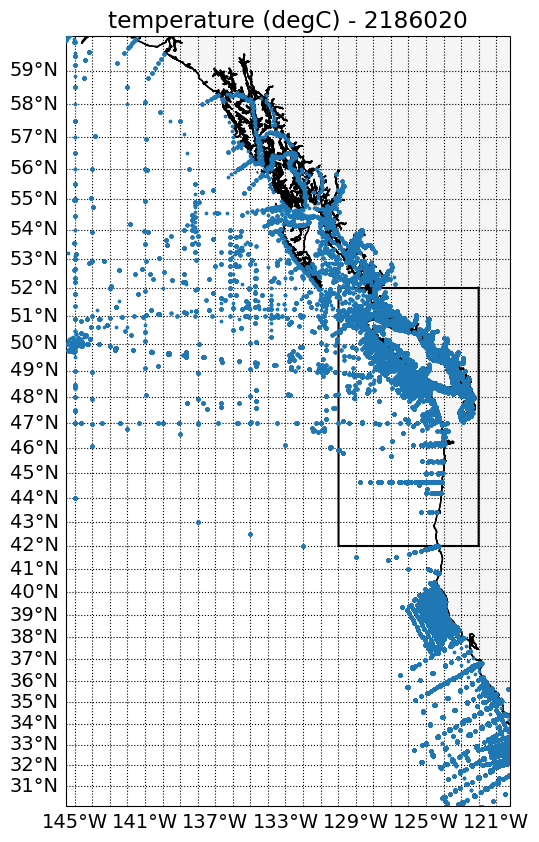

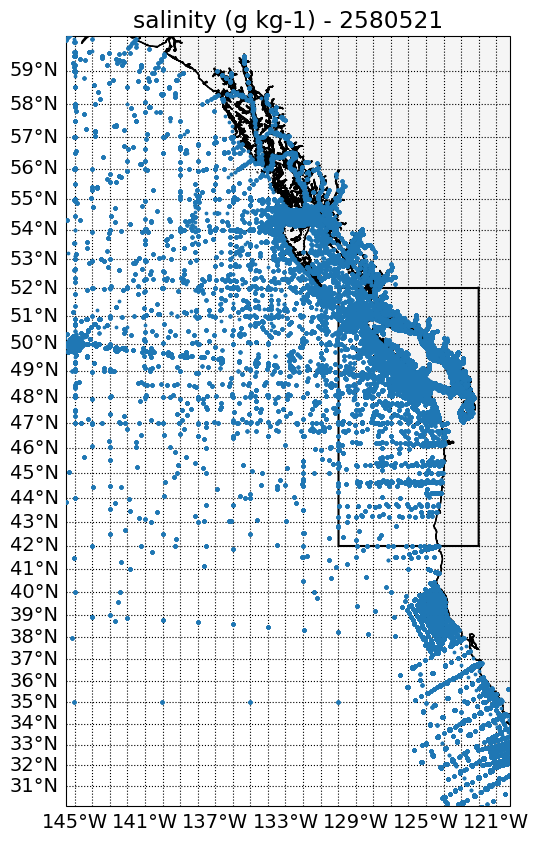

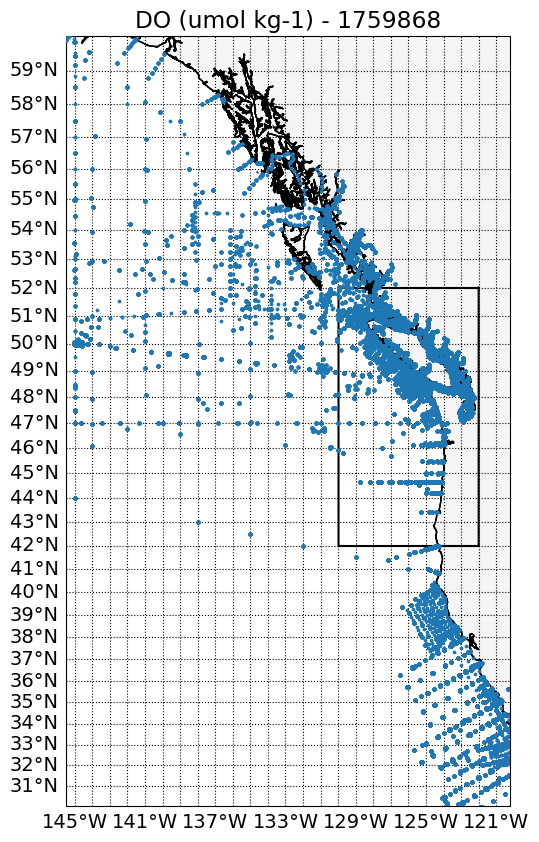

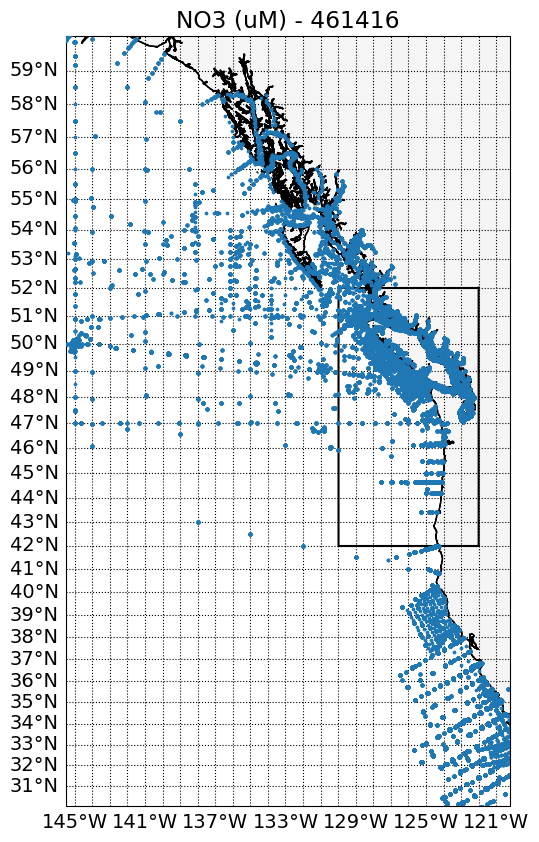

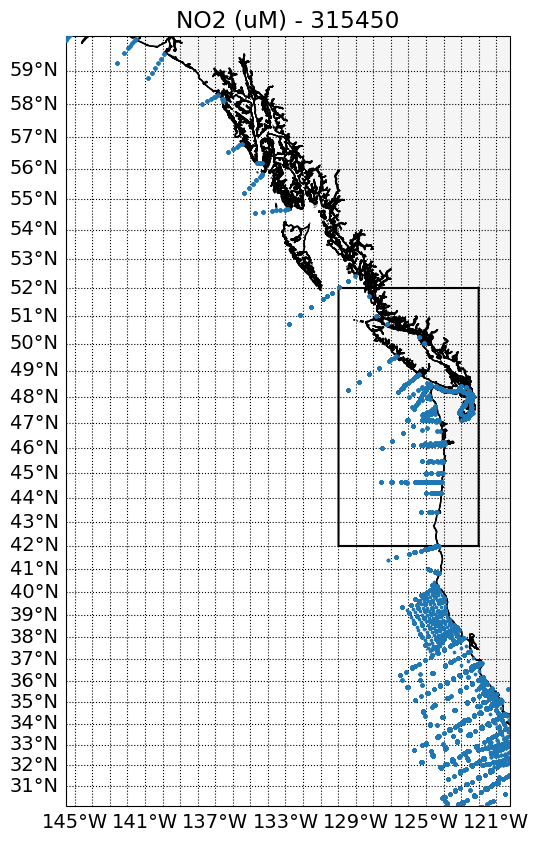

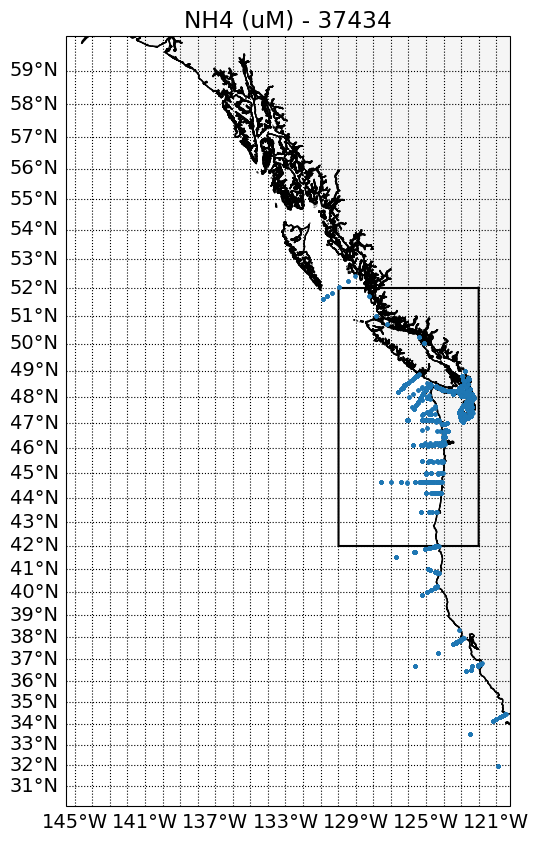

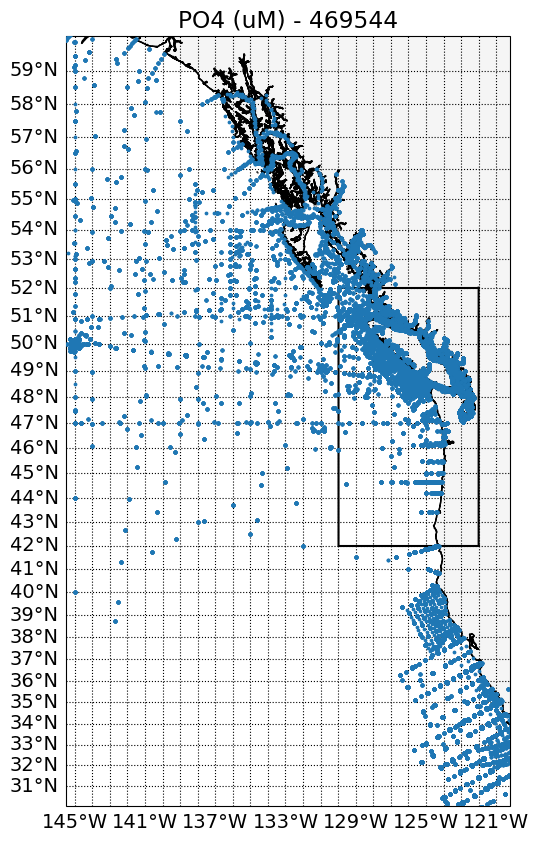

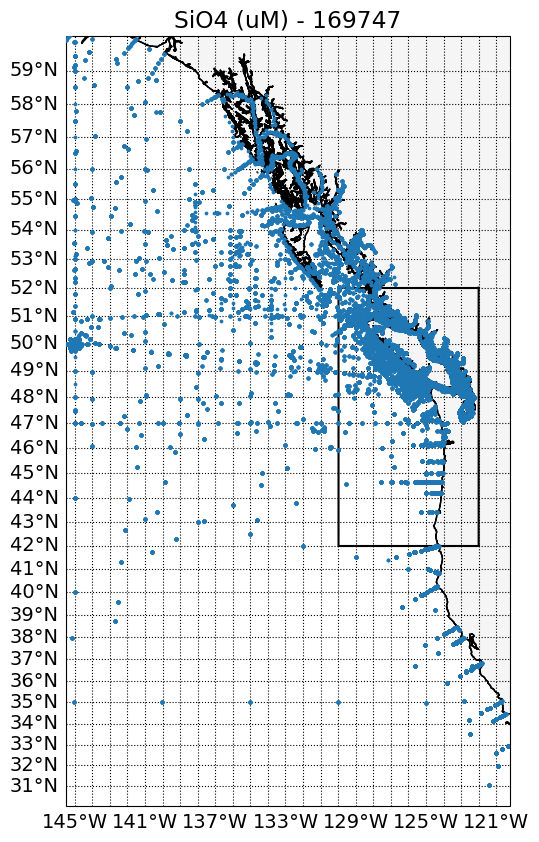

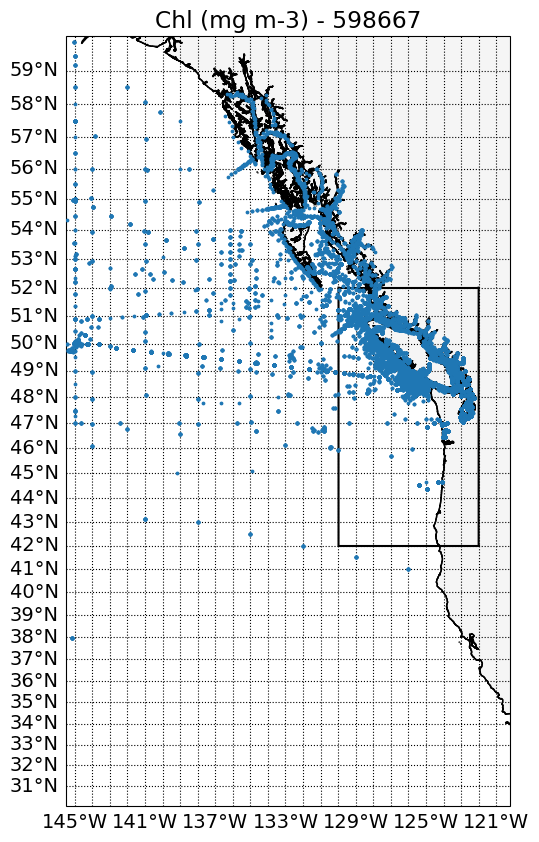

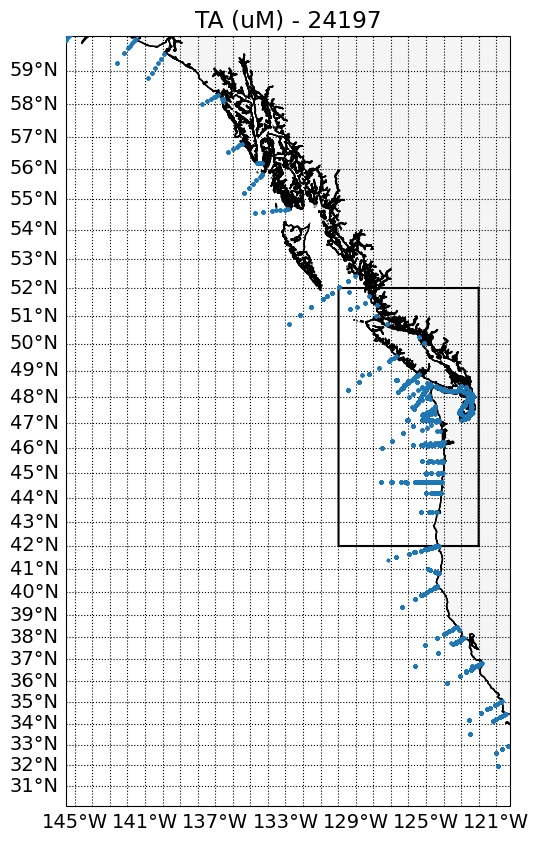

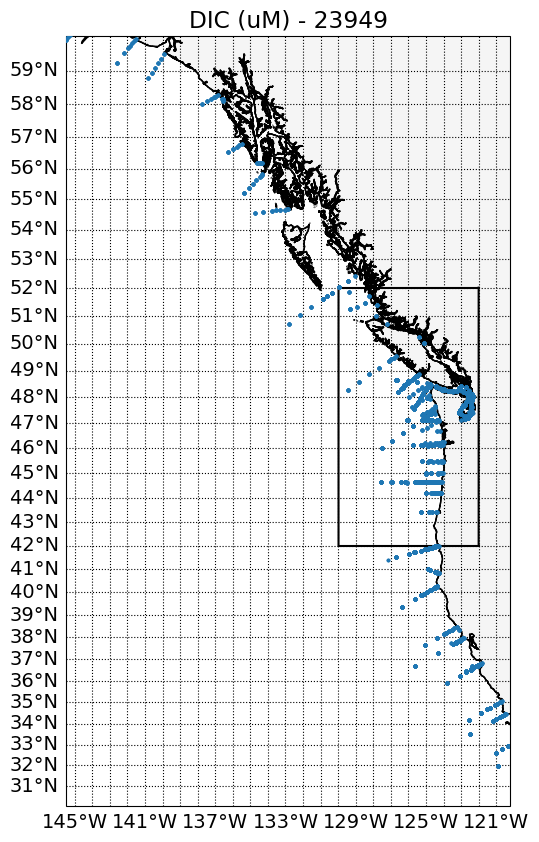

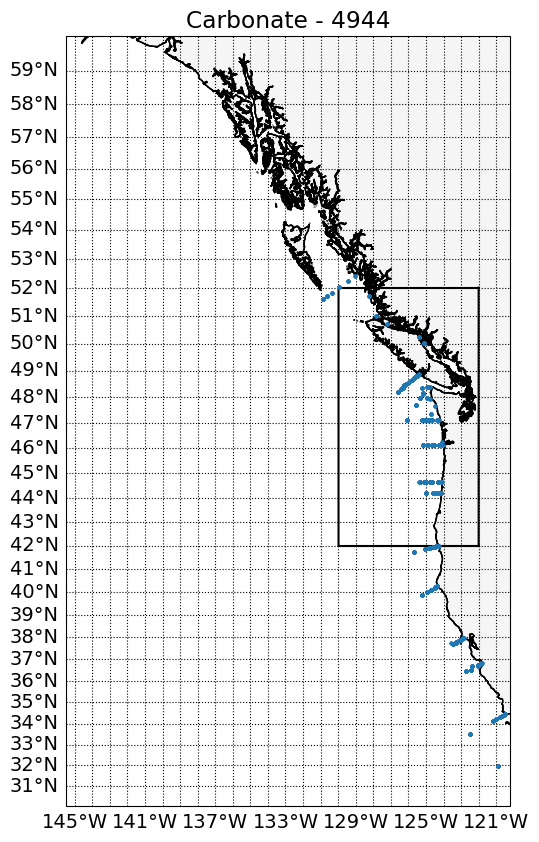

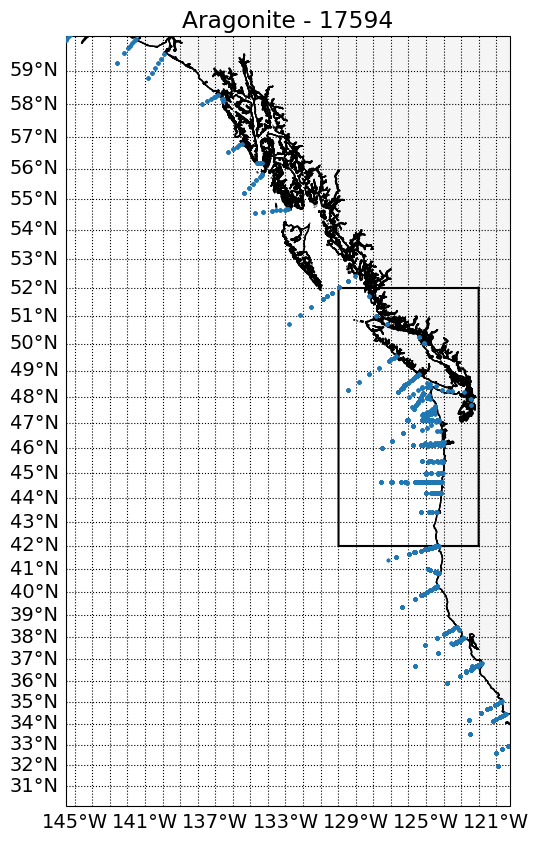

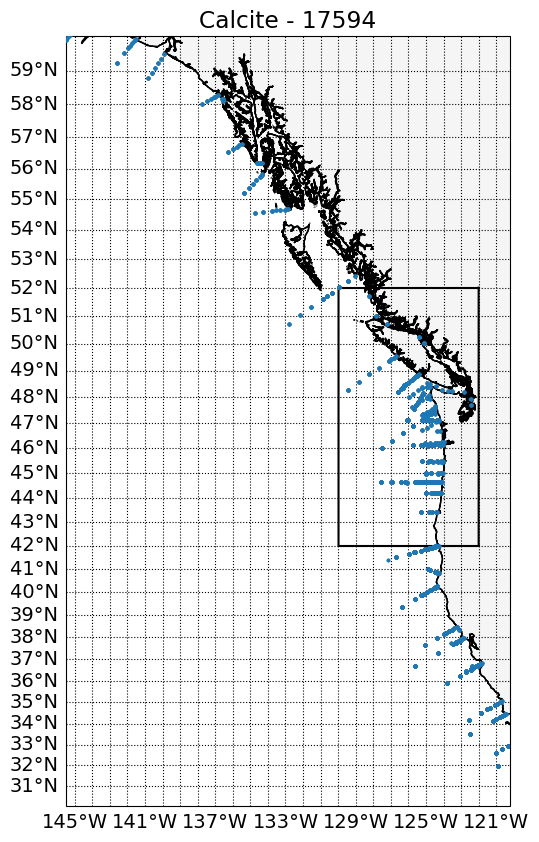

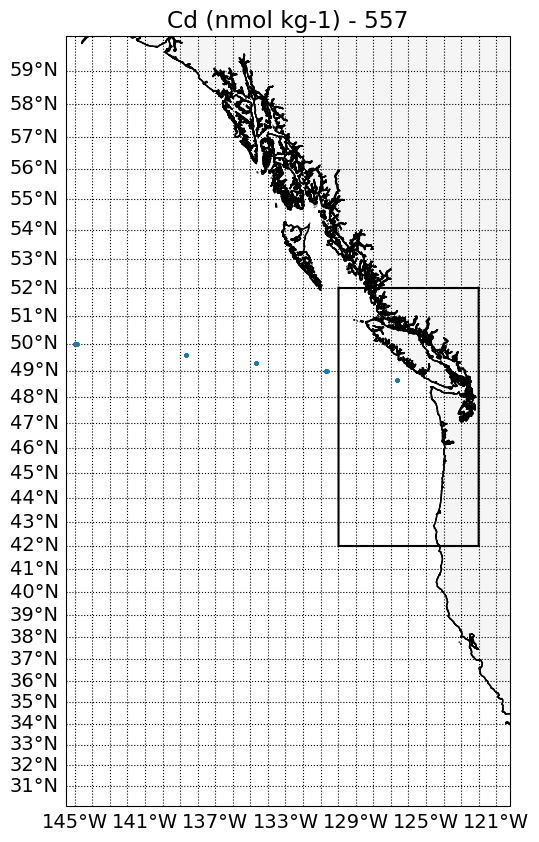

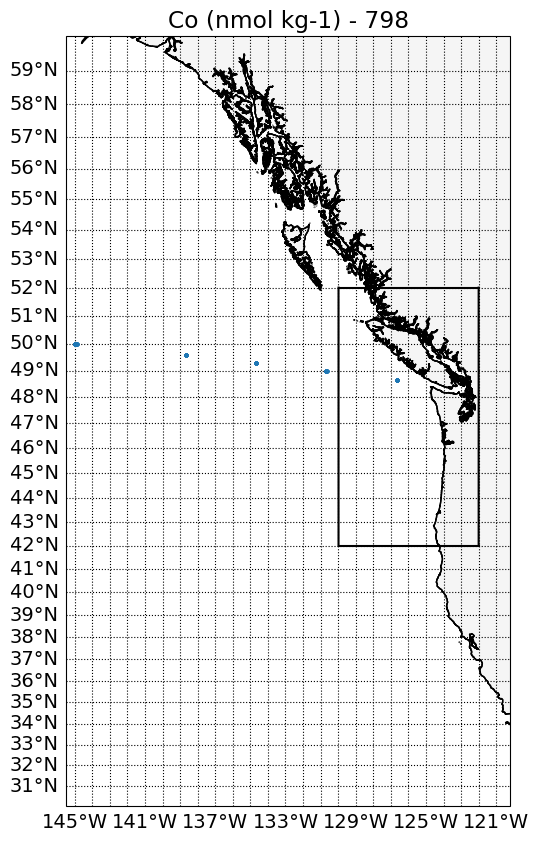

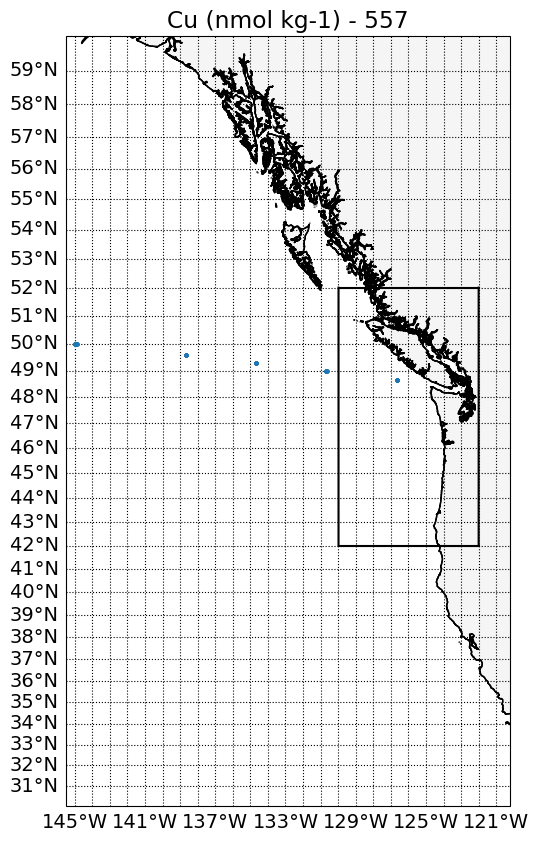

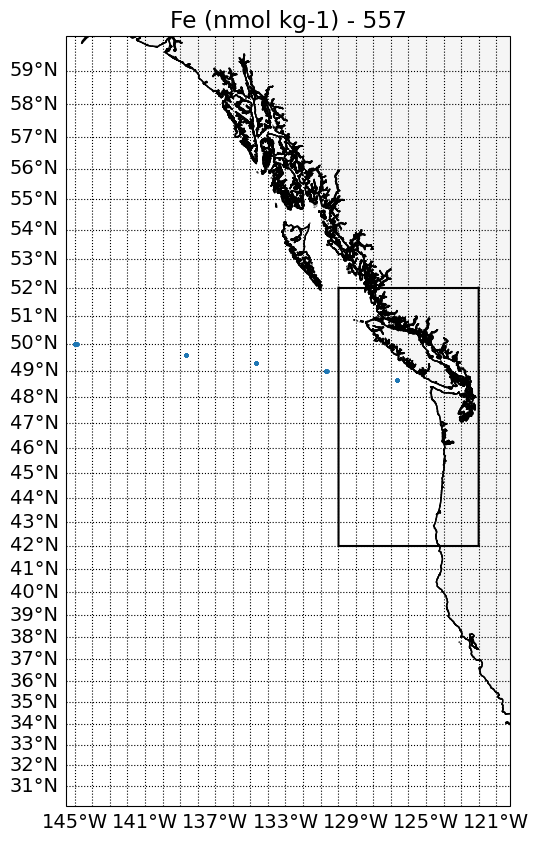

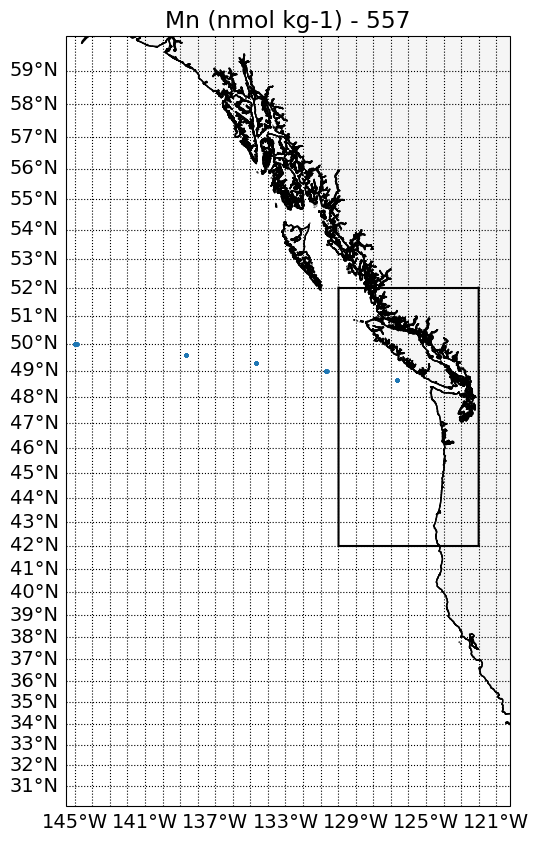

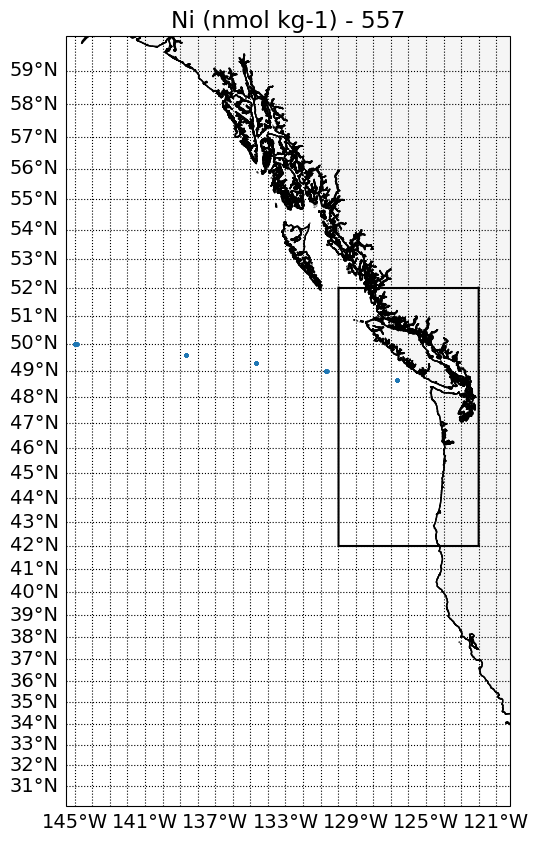

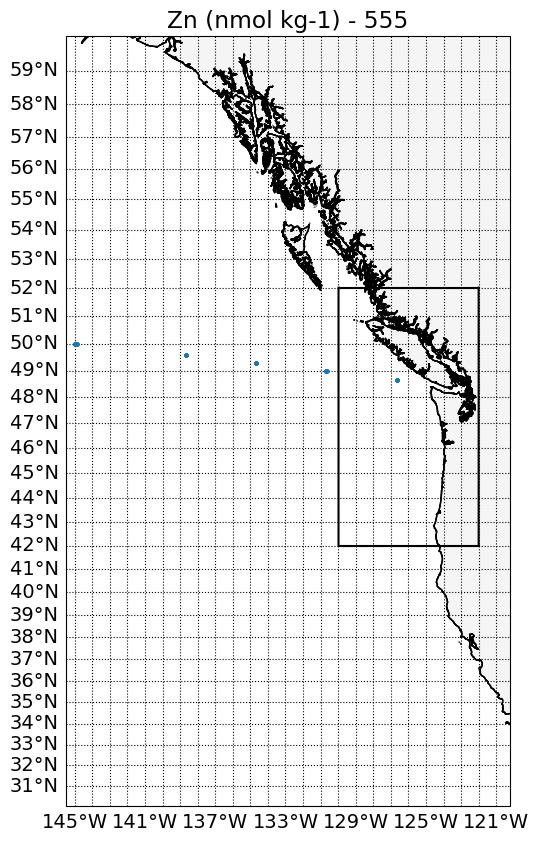

In [124]:
for tracer in columns_to_count:
    # Increase font size
    plt.rcParams['font.size'] = 14

    # Make plot area
    xlim, ylim = [-145.5, -120.2], [30, 60]
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
    ax.set_extent(xlim + ylim)

    # Draw coastline
    ax.add_feature(feature.GSHHSFeature('full', facecolor='whitesmoke', zorder=2))
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='k', zorder=4))

    # Add gridlines
    xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
    gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.top_labels, gl.right_labels = False, False

    # Draw box
    ax.plot(grid.lon_rho[:,0], grid.lat_rho[:,0], 'k-', zorder=6, transform=crs.PlateCarree())
    ax.plot(grid.lon_rho[:,-1], grid.lat_rho[:,-1], 'k-', zorder=6, transform=crs.PlateCarree())
    ax.plot(grid.lon_rho[-1,:], grid.lat_rho[-1,:], 'k-', zorder=6, transform=crs.PlateCarree())
    ax.plot(grid.lon_rho[0,:], grid.lat_rho[0,:], 'k-', zorder=6, transform=crs.PlateCarree())

    # add points
    ax.scatter(ob['longitude (degrees_east)'][~np.isnan(ob[tracer])], ob['latitude (degrees_north)'][~np.isnan(ob[tracer])], s=3, transform=crs.PlateCarree(),zorder=7)

    title = "{} - {}".format(tracer,np.sum(~np.isnan(ob[tracer])))
    ax.set_title(title)

In [125]:
set(ob.source)

{'CALCOFI',
 'GEOTRACES',
 'NCEI Coastal',
 'NCEI Coastal, NHL',
 'NCEI PNW',
 'NCEI Salish',
 'NHL',
 'OCNMS',
 'department of ecology',
 'department of ecology, NCEI Salish',
 'ios bottle',
 'ios bottle, GEOTRACES',
 'ios bottle, NCEI PNW',
 'ios bottle, NCEI PNW, GEOTRACES',
 'ios ctd profiles',
 'ios ctd profiles, ios bottle',
 'ios mooring',
 'ios mooring, ios bottle',
 'onc',
 'ooi'}

In [126]:
for tracer in columns_to_count:
    print(tracer)
    print(set(ob.source[~np.isnan(ob[tracer])]))
    print("\n")

temperature (degC)
{'NCEI PNW', 'ios ctd profiles', 'ios bottle', 'department of ecology', 'OCNMS', 'department of ecology, NCEI Salish', 'NHL', 'ios bottle, NCEI PNW, GEOTRACES', 'NCEI Coastal', 'NCEI Coastal, NHL', 'ios bottle, NCEI PNW', 'ooi', 'CALCOFI', 'ios ctd profiles, ios bottle', 'onc', 'GEOTRACES', 'ios bottle, GEOTRACES', 'NCEI Salish', 'ios mooring, ios bottle', 'ios mooring'}


salinity (g kg-1)
{'NCEI PNW', 'ios ctd profiles', 'ios bottle', 'department of ecology', 'OCNMS', 'department of ecology, NCEI Salish', 'NHL', 'ios bottle, NCEI PNW, GEOTRACES', 'NCEI Coastal', 'NCEI Coastal, NHL', 'ios bottle, NCEI PNW', 'ooi', 'CALCOFI', 'ios ctd profiles, ios bottle', 'onc', 'GEOTRACES', 'ios bottle, GEOTRACES', 'NCEI Salish', 'ios mooring, ios bottle', 'ios mooring'}


DO (umol kg-1)
{'NCEI PNW', 'ios ctd profiles', 'ios bottle', 'department of ecology', 'OCNMS', 'department of ecology, NCEI Salish', 'NHL', 'ios bottle, NCEI PNW, GEOTRACES', 'NCEI Coastal', 'NCEI Coastal, NHL'

In [127]:
# calculate N* and spice here
# N∗=(N−16×P)+2.9
no3 = oxygen_uM_to_umolkg(ob['NO3 (uM)'], ob['salinity (g kg-1)'], ob['temperature (degC)'], ob['pressure (dbar)'])
po4 = oxygen_uM_to_umolkg(ob['PO4 (uM)'], ob['salinity (g kg-1)'], ob['temperature (degC)'], ob['pressure (dbar)'])
ob['Nstar (umol kg-1)'] = (no3-(16*po4)+2.9)*0.87 # equation 13 in Gruber & Sarmiento (1997)

# calculate spice
CT = gsw.conversions.CT_from_t(ob['salinity (g kg-1)'], ob['temperature (degC)'], ob['pressure (dbar)'])
ob['spice'] = gsw.spiciness0(ob['salinity (g kg-1)'], ob['temperature (degC)'])
 

In [129]:
#ob.to_csv('/data/rbeutel/obs/PNW_obs_compiled.csv')
ob.to_csv('/ocean/ghoeven/MOAD/Data/PNW_obs_compiled.csv')